# Graph-Conditioned Parameterization for QAOA on Transcriptomic Graphs

**Depth-2 QAOA Experiments on Transcriptomic Co-Expression Graphs**

---

## Abstract

This analysis studies whether graph-conditioned parameterization can predict depth-2 QAOA angles for real transcriptomic co-expression graphs while preserving approximation quality relative to direct classical search. The emphasis is on held-out approximation ratio, learned-initializer comparisons, optimization geometry, and runtime.

## Experimental Scope

- Real transcriptomic co-expression graphs derived from prostate expression data.
- Exact depth-2 statevector simulation for MaxCut.
- Comparisons against direct classical search, heuristic initialization, graph-ablated variants, and a prior-style learned regressor.

## Results at a Glance

| Metric | Value |
|---|---|
| Representative classical ratio | **0.8976** |
| Representative adapted GNN ratio | **0.8975** |
| Mean held-out classical ratio | **0.8686** |
| Mean held-out adapted GNN ratio | **0.8682** |
| Held-out quality retention | **99.95%** |
| Lift over prior-style learned baseline | **0.8208 -> 0.8682** mean ratio |
| Median speedup | **2,640x** |

## Experimental Questions

- How closely can learned graph-conditioned angles match direct classical depth-2 search on held-out graphs?
- How much of the performance depends on graph edges, node features, and transcriptomic adaptation?
- What latency reduction is obtained relative to direct search?
- What do the landscape and state-concentration diagnostics reveal about the learned proposals?

## Experimental Roadmap

The analysis proceeds from graph construction and representative-problem setup to held-out evaluation, initializer comparison, and diagnostic analysis.

| Part | Focus | Main outputs |
|---|---|---|
| I | Transcriptomic graph construction and representative setup | graph statistics, representative instance, target parameters |
| II | Held-out benchmark against direct classical search | approximation ratios, retention, runtime summary |
| III | Learned-initializer comparison and ablations | prior-style baseline, graph ablations, convergence behavior |
| IV | Diagnostic analysis | landscape geometry, state concentration, residual regret |

## Visual Evidence Gallery

These saved figures surface the strongest evidence before the implementation details. The later result sections reproduce the same figures live; the gallery exists so the exported HTML and opening sections both carry the most important visual record.

### Held-Out Benchmark Overview

![Three-panel benchmark figure summarizing median latency across held-out transcriptomic graphs, the representative depth-2 output-state concentration, and per-graph approximation-ratio comparisons between classical search, the adapted GNN, and the legacy transfer baseline.](figures/qaoa_demo_benchmark_overview.png)

### Landscape Geometry

![Two-panel landscape-geometry figure showing the distribution of values in the representative depth-2 slice and the fraction of slice grid points that remain near the optimum.](figures/qaoa_demo_landscape_geometry.png)

### Quantum State Concentration

![Two-panel state-concentration figure comparing cut value against QAOA measurement probability and showing the cumulative concentration of probability mass on high-quality bitstrings versus a uniform baseline.](figures/qaoa_demo_state_concentration.png)

### Residual Regret and Lift Over Transfer

![Three-panel regret analysis summarizing residual regret on each held-out transcriptomic graph, adapted-versus-classical parity, and the lift over the original legacy transfer baseline.](figures/qaoa_demo_residual_regret.png)

## 0. Introduction

<a name="intro"></a>

### Problem Formulation

This experiment asks whether a graph neural network can map transcriptomic co-expression structure to useful depth-2 QAOA angles for MaxCut. The workflow is explicit: construct a real-data graph family, solve representative and held-out instances with direct classical search, train a learned parameter generator on resampled graphs, and compare approximation quality and latency on held-out graphs.

The MaxCut problem asks: given a weighted graph $G = (V, E, w)$, find a partition $(S, \bar{S})$ of $V$ that maximises the total weight of edges crossing the cut,

$$
\text{MaxCut}(G) = \max_{S \subseteq V} \sum_{(u,v)\in E} w_{uv} \cdot \mathbf{1}\bigl[(u \in S) \oplus (v \in S)\bigr].
$$

MaxCut is NP-hard in general. The Goemans-Williamson SDP achieves an approximation ratio of $\alpha_{GW} \approx 0.878$. The Quantum Approximate Optimization Algorithm (QAOA) of depth $p$ provides a parameterised quantum circuit whose expected cut value approaches MaxCut as $p \to \infty$.

---

### Biological Context

The graph is derived from the **OpenML `prostate` transcriptomic dataset** (102 patients × 12,600 RNA expression features). The pipeline selects the 10 highest-variance genes and encodes pairwise Pearson correlations as edge weights, yielding a biologically grounded co-expression structure.

**Why MaxCut on co-expression graphs?** A cut on a co-expression graph separates genes whose coordinated activity is strongest across the cohort. Even though this is not itself a clinical endpoint, it is a technically meaningful stress test for whether a learned graph model can map biologically derived structure into useful QAOA angle proposals.

---

### Experimental Shift Relative to the Earlier Depth-1 Study

The present workflow changes the earlier setup in two concrete ways.

| Change in protocol | Why it matters |
|---------|----------------|
| **Depth-2 QAOA instead of depth-1** | Raises the quality ceiling on these transcriptomic MaxCut instances |
| **Transcriptomic domain adaptation on separate resampled graphs** | Replaces out-of-domain transfer with a graph family that matches the benchmark distribution |

The resulting comparison is narrower and more useful: the question is no longer whether a learned initializer is merely fast, but whether it can retain nearly all of the depth-2 classical quality on held-out real-data graphs.

---

### Scope and Limitations (Up Front)

- **Statevector simulation** is exact but scales as $O(2^n)$; here $n = 10$ is intentionally small enough to keep the benchmark fully auditable.
- **Depth $p = 2$** is stronger than the previous $p = 1$ setup, but it is still a low-depth ansatz rather than an asymptotic quantum-advantage claim.
- **Domain adaptation is still small-data supervision**: the adapted graph model is trained on transcriptomic resamples from the same cohort family, not on independent external cohorts.
- **Gene selection is variance-based** rather than pathway-aware, so the derived graph remains algorithmically motivated more than biologically curated.
- **The benchmark is intentionally strict**: exact MaxCut is computed for every graph, so all quality claims are measured against ground truth rather than against another heuristic.

## 1. Quantum Computing Foundations <a name="qc-foundations"></a>

### The Qubit

A **qubit** is the quantum counterpart of a classical bit.  Unlike a classical bit constrained to $\{0,1\}$, a qubit exists in a **superposition**:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \quad \alpha, \beta \in \mathbb{C}, \quad |\alpha|^2 + |\beta|^2 = 1$$

where $|0\rangle = \begin{pmatrix}1\\0\end{pmatrix}$ and $|1\rangle = \begin{pmatrix}0\\1\end{pmatrix}$ are the standard computational basis states.

### Multi-Qubit Register

An $n$-qubit register spans a $2^n$-dimensional Hilbert space.  A general state is:

$$|\psi\rangle = \sum_{x \in \{0,1\}^n} \alpha_x |x\rangle, \qquad \sum_x |\alpha_x|^2 = 1$$

Our simulator stores this as a **numpy array of $2^n$ complex amplitudes** — the *statevector*.

### Essential Quantum Gates

| Gate | Symbol | Matrix | Action on qubit |
|------|--------|--------|----------------|
| Hadamard | $H$ | $\frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | $|0\rangle \to |+\rangle = \frac{|0\rangle+|1\rangle}{\sqrt{2}}$ |
| Pauli-Z | $Z$ | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | Phase flip: $|1\rangle \to -|1\rangle$ |
| Pauli-X | $X$ | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | Bit flip: $|0\rangle \to |1\rangle$ |
| $R_Z(\theta)$ | $R_Z$ | $\begin{pmatrix}e^{-i\theta/2}&0\\0&e^{i\theta/2}\end{pmatrix}$ | Rotation around Z-axis |
| $R_X(\theta)$ | $R_X$ | $\begin{pmatrix}\cos\theta/2 & -i\sin\theta/2 \\ -i\sin\theta/2 & \cos\theta/2\end{pmatrix}$ | Rotation around X-axis |

### QAOA-Specific Operators

The QAOA circuit uses two types of evolution operators:

**Cost unitary** (encodes the problem):
$$U_C(\gamma) = e^{-i\gamma C} = \prod_{(u,v)\in E} e^{-i\gamma \frac{1}{2}(I - Z_u Z_v)}$$

In circuit form: a $ZZ$-rotation between each edge pair — implemented as $R_{ZZ}(\gamma) = e^{-i\gamma Z\otimes Z}$.

**Mixing unitary** (explores the state space):
$$U_B(\beta) = e^{-i\beta B} = \prod_{i=1}^n e^{-i\beta X_i} = \prod_{i=1}^n R_X(2\beta)$$

where $B = \sum_i X_i$ is the transverse-field Hamiltonian (maximally mixed over bit strings).

### The Variational State at Depth $p$

Starting from the uniform superposition $|+\rangle^{\otimes n} = H^{\otimes n}|0\rangle^{\otimes n}$, we alternate $p$ rounds of cost and mixing unitaries:

$$|\boldsymbol\gamma, \boldsymbol\beta\rangle = U_B(\beta_p)U_C(\gamma_p)\cdots U_B(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}$$

At $p=1$ there are only 2 free parameters: $(\gamma_1, \beta_1)$. As $p \to \infty$, QAOA approaches the **quantum adiabatic algorithm** (exact solution).

## 1A. Quantum Foundations

The previous section introduced the formal mathematical notation. This bridge section translates every key idea into everyday language before you move on. Read it alongside the formal section, not instead of it.

---

### Qubits

A classical bit is like a coin lying flat on a table: it is either heads (0) or tails (1).

A qubit is like a coin that is spinning in the air: while it spins, it carries both possibilities at once. When you catch it (measure it), it lands on one side, and from that point it behaves like a regular bit.

The fractions $|\alpha|^2$ and $|\beta|^2$ in the formal section just say:
- $|\alpha|^2$ is the probability of landing on 0
- $|\beta|^2$ is the probability of landing on 1

Because one of those must happen, the two probabilities must add up to exactly 1. That is why $|\alpha|^2 + |\beta|^2 = 1$.

---

### Multiple qubits: the exponential advantage

When you have $n$ qubits together, the number of "spinning coin" combinations grows exponentially. With 6 qubits there are $2^6 = 64$ possible states. With 20 qubits there are $2^{20} \approx 1{,}000{,}000$ states.

The quantum state vector stores one complex number for each of these combinations. So the simulator here stores 64 complex numbers for $n=6$ qubits.

This exponential growth is exactly why quantum computers could eventually outperform classical ones on certain problems: they can represent and manipulate an exponentially large space in a compact physical system.

---

### Quantum gates: rotating the coin mid-spin

A quantum gate is just a transformation applied to qubits while they are still in superposition.

The **Hadamard gate (H)** is the starting gate used in QAOA. It takes a qubit sitting at 0 and puts it exactly halfway between 0 and 1, an equal superposition. Applied to all $n$ qubits at once, the whole register is now in an equal mix of all $2^n$ possible bit strings. That is the starting point for QAOA.

The **R_Z** and **R_X** gates are rotation gates. They rotate the qubit state by a controllable angle. Think of tilting the spinning coin in a specific direction by a specific amount.

In QAOA:
- **R_ZZ** gates (applied between pairs of connected qubits) encode the MaxCut problem structure
- **R_X** gates (applied to each qubit independently) push the state toward mixing all possibilities

---

### The two parameters gamma and beta

$\gamma$ (gamma) controls the cost evolution. It sets how strongly the circuit "feels" the graph structure when it evolves. Large $\gamma$ means the problem cost has a big effect on the quantum state; small $\gamma$ means a weaker effect.

$\beta$ (beta) controls the mixing evolution. It sets how much the circuit explores all possibilities versus focusing. After the cost gates have biased the state toward good solutions, the mixer adjusts how far the state spreads out.

Together, finding the right $(\gamma, \beta)$ pair is the main challenge QAOA solves. That is precisely what this analysis compares: finding them by classical trial-and-error versus predicting them with a GNN.

---

### The QAOA circuit as a recipe

At depth $p=1$, the QAOA circuit follows this exact sequence:

1. Put all qubits into equal superposition using Hadamard gates.
2. Apply cost gates controlled by $\gamma$ between every pair of connected nodes.
3. Apply mixing gates controlled by $\beta$ to every qubit independently.
4. Measure the result.

The measurement gives a bit string, e.g. `010110`, which is interpreted as an assignment of nodes to Group A (0 bits) and Group B (1 bits). The number of cut edges for that bit string is the score.

Running the circuit many times and averaging the scores gives the expected cut value $\langle C \rangle$. Maximizing that quantity over $(\gamma, \beta)$ is the optimization problem.

---

### Mental model to carry forward

For the rest of this analysis, keep this single picture in mind:

- The quantum circuit produces a probability distribution over all $2^n$ bit strings.
- Each bit string represents one possible way to split the graph nodes.
- The circuit parameters $\gamma$ and $\beta$ shape that distribution.
- Good parameters mean high-cut bit strings are highly probable.
- The GNN predicts good parameters directly from the graph structure.

## 2. MaxCut Problem — Definition & Complexity <a name="maxcut"></a>

### Problem Statement

Given an undirected, unweighted graph $G = (V, E)$ with $|V| = n$ vertices, the **MaxCut** problem seeks a bipartition $(S, \bar{S})$ of $V$ that maximises the number of edges crossing the cut:

$$\text{MaxCut}(G) = \max_{S \subseteq V} \left|\{(u,v) \in E : u \in S,\; v \notin S\}\right|$$

**Example — Complete graph $K_4$:** 4 nodes, 6 edges.  The max cut is 4 (split into 2+2).

### NP-Hardness

MaxCut is **NP-hard** in the strong sense (Garey & Johnson, 1979).  The decision version (does there exist a cut of size $\geq k$?) is NP-complete.

Key complexities:

| Algorithm | Complexity | Approximation ratio |
|-----------|-----------|---------------------|
| Exhaustive search | $O(2^n m)$ | 1.0 (exact) |
| Random bipartition | $O(m)$ | 0.5 (in expectation) |
| Goemans–Williamson SDP | $O(n^{3.5})$ | ≥ 0.878 |
| QAOA $p=1$ | $O(p \cdot 2^n)$ | 0.6924 on 3-regular graphs |

The famous **Goemans–Williamson** (1995) algorithm achieves a 0.878-approximation via semidefinite programming — conjectured optimal under the **Unique Games Conjecture** (Khot 2002).

### QAOA Cost Hamiltonian Derivation

We encode MaxCut as a Hamiltonian.  Map each bipartition to a binary string $\mathbf{z} \in \{-1,+1\}^n$ where $z_i = +1 \Leftrightarrow i \in S$.

An edge $(u,v)$ is cut iff $z_u \neq z_v$, i.e., $z_u z_v = -1$.  The number of cut edges is:

$$C(\mathbf{z}) = \sum_{(u,v)\in E} \frac{1 - z_u z_v}{2}$$

Promoting $z_i \to Z_i$ (Pauli-Z operator acting on qubit $i$):

$$\hat{C} = \frac{1}{2}\sum_{(u,v)\in E}(I - Z_u Z_v)$$

The MaxCut value is the **largest eigenvalue** of $\hat{C}$, and QAOA maximises $\langle\psi|\hat{C}|\psi\rangle$ over states in the variational family.

### At $p=1$: Closed-Form Expected Value

For depth $p=1$ on a 3-regular graph with $n$ vertices and $m = 3n/2$ edges, the expected cut value has a closed form:

$$\langle C \rangle_{p=1}(\gamma, \beta) = \frac{m}{2} + \frac{m}{2}\sin(4\beta)\sin(\gamma)\cos^{d-1}(\gamma/2)\cdots$$

where $d$ is the degree.  For general graphs this is computed numerically via statevector simulation.

## 2A. MaxCut — From Puzzle to Quantum Hamiltonian

The formal section above is dense. This bridge section rebuilds the same ideas in plain language and links them to the real genomics workflow used later in the analysis.

---

### What is MaxCut here?

MaxCut is still a graph partitioning problem, but here the graph is a **gene co-expression network**. Each node is one selected gene, and each edge marks a strong pairwise expression relationship in the cohort.

The optimization question is therefore not abstract. It asks how the graph of coordinated gene activity can be split into two strongly separated groups.

---

### Why is that useful?

In a biological network, strong connections often indicate genes that move together across patients. Partitioning such a graph can highlight competing or complementary structure in the data.

This analysis does not claim that MaxCut is the only or definitive genomics objective. Instead, it uses MaxCut as a clean and interpretable graph-optimization testbed built from real transcriptomic measurements.

---

### Converting MaxCut into a score formula

The formal section introduced the score

$$C(\mathbf{z}) = \sum_{(u,v)\in E} \frac{1 - z_u z_v}{2}$$

Plain-English meaning:
- if two connected genes are placed in different groups, the edge contributes 1,
- if they stay in the same group, the edge contributes 0,
- the total score counts how many strong co-expression links are separated by the partition.

---

### How does this become a quantum problem?

The graph score is encoded as a quantum Hamiltonian,

$$\hat{C} = \frac{1}{2}\sum_{(u,v)\in E}(I - Z_u Z_v)$$

and QAOA searches for circuit angles that produce a quantum state favoring high-scoring partitions.

So the workflow is:
- start with real gene-expression data,
- derive a co-expression graph,
- encode that graph as a MaxCut Hamiltonian,
- optimize or predict the QAOA angles.

---

### Approximation ratio: measuring how well we did

The approximation ratio is

$$r = \frac{\text{expected cut}}{\text{exact MaxCut}}$$

A value near 1.0 means the QAOA state is placing high probability on strong graph partitions. Lower values indicate that either the circuit depth is limited, the angle choice is weaker, or the learned predictor has not fully captured the graph structure.

---

### Key takeaway before the code

The remainder of the analysis derives graph instances from a real prostate gene-expression dataset, studies one full-cohort graph in detail, and then evaluates several patient-resampled graphs to compare classical QAOA parameter search with GNN-predicted parameters.

The main outputs to track are:
- expected cut $\langle C \rangle$,
- approximation ratio against exact MaxCut,
- latency difference between iterative classical search and one-pass GNN inference.

## 3. Statevector Simulation — How the Code Works <a name="simulation"></a>

### Exact Statevector Approach

Our simulator (`src/qaoa_sim.py`) maintains the full $2^n$-dimensional complex amplitude vector.  Operations are applied as tensor contractions:

**Applying a 1-qubit gate** $U$ to qubit $k$:

1. Reshape statevector: $|\psi\rangle \in \mathbb{C}^{2^n} \to \mathbb{C}^{2^k \times 2 \times 2^{n-k-1}}$
2. Contract along axis 1: `np.einsum('ab,...b...->...a...', U, psi)`
3. Reshape back to $\mathbb{C}^{2^n}$

**Applying $U_C(\gamma)$ for MaxCut:**  
For each edge $(u,v)$, apply the $RZZ$ gate to qubits $u, v$:

$$R_{ZZ}(\theta) = e^{-i\theta Z\otimes Z/2} = \begin{pmatrix}e^{-i\theta/2} & & & \\ & e^{i\theta/2} & & \\ & & e^{i\theta/2} & \\ & & & e^{-i\theta/2}\end{pmatrix}$$

This is equivalent to: `CNOT(u,v)` → `Rz(2γ)` on `v` → `CNOT(u,v)`.

**Applying $U_B(\beta)$:**  
Independent rotations $R_X(2\beta)$ on each qubit — $O(n)$ operations.

**Computing $\langle C\rangle$:**

$$\langle C\rangle = \langle\psi|\hat{C}|\psi\rangle = \frac{1}{2}\sum_{(u,v)\in E}\left(1 - \langle\psi|Z_u Z_v|\psi\rangle\right)$$

Each $\langle Z_u Z_v\rangle$ is computed as:

$$\langle Z_u Z_v\rangle = \sum_{x\in\{0,1\}^n} (-1)^{x_u + x_v}|\alpha_x|^2$$

using the probabilities $|\alpha_x|^2$ from the statevector.

### Complexity Analysis

| Operation | Time | Space |
|-----------|------|-------|
| $H^{\otimes n}$ initialisation | $O(2^n)$ | $O(2^n)$ |
| $U_C(\gamma)$ — $m$ RZZ gates | $O(m \cdot 2^n)$ | $O(2^n)$ |
| $U_B(\beta)$ — $n$ RX gates | $O(n \cdot 2^n)$ | $O(2^n)$ |
| $\langle C\rangle$ measurement | $O(m \cdot 2^n)$ | $O(2^n)$ |
| **Total per evaluation** | $O((n+m) \cdot 2^n)$ | $O(2^n)$ |

For $n=6$: $2^6=64$ amplitudes — trivially fast.  For $n=12$: $2^{12}=4096$ — still manageable.  For $n=20$: $2^{20} \approx 10^6$ — ~16 MB for complex128, borderline feasible.  For $n=30$: $2^{30} \approx 10^9$ — infeasible in this exact simulation setting.

### Alternative Simulation Methods for Larger $n$

| Method | Max $n$ | Notes |
|--------|---------|-------|
| Dense statevector (NumPy) | ~20 | Exact, $O(2^n)$ memory |
| Tensor network (MPS) | ~50-100 | Approximate for low entanglement |
| Clifford simulator | Unlimited | Only Clifford circuits |
| FPGA/GPU accelerated | ~30-35 | 1000× speedup |
| Qiskit Aer GPU | ~30 | Accelerated cuStateVec-style backend |

## 3A. Simulation Primer — What the Code Is Actually Doing

The formal section explains the mechanics of the simulator. This bridge explains what the simulation is trying to accomplish and how to think about each piece.

---

### The state vector is a lookup table

Rather than running the circuit on real quantum hardware (where you can only measure, not read amplitudes directly), the simulator stores the full state in memory.

For $n = 6$ qubits, there are $2^6 = 64$ possible bit strings: `000000`, `000001`, ..., `111111`.

The state vector is a list of 64 complex numbers, one per bit string. Each number's magnitude-squared is the probability of getting that bit string when you measure.

Right at the start (before any gates), the Hadamard layer makes all 64 probabilities equal at $1/64 \approx 1.6\%$. Every split is equally likely before the circuit does any work.

---

### What the cost gates do

After the equal-superposition start, the cost gates ($R_{ZZ}$ gates) rotate the amplitudes of different bit strings by different amounts depending on whether the corresponding edge is cut.

Concretely, for each edge $(u, v)$ in the graph, a $R_{ZZ}(\gamma)$ gate is applied to qubits $u$ and $v$. This gate:
- Does nothing if qubits $u$ and $v$ are in the same state (both 0 or both 1) — this corresponds to a non-cut edge.
- Applies a phase rotation of $e^{-i\gamma}$ if the qubits are in different states — this corresponds to a cut edge.

After all cost gates, bit strings representing good cuts have accumulated a different phase than bit strings representing poor cuts.

---

### What the mixer gates do

The mixer gates ($R_X(2\beta)$ gates) then "interfere" these different phases. Quantum interference is the mechanism that amplifies bit strings with accumulated advantageous phases and suppresses others.

Think of it like ripples on water. Two waves with the same phase reinforce each other (constructive interference). Two waves with opposite phases cancel out (destructive interference).

The mixer gate creates these interference effects, causing high-cut bit strings to become more probable and low-cut bit strings to become less probable — but only if $\gamma$ and $\beta$ are chosen well.

---

### Why we simulate classically on small graphs

On a real quantum computer, you cannot directly read the state vector; you can only measure it (getting one random bit string). To estimate probabilities, you run the circuit hundreds or thousands of times.

For the purposes of this tutorial, we run a classical simulation that computes the state vector exactly once. This gives exact probabilities without measurement noise. The trade-off: the simulator uses $O(2^n)$ memory, so it only works for small $n$ (up to about 20 on a laptop).

---

### How to map simulator output to a MaxCut solution

After running the simulator with specific $(\gamma, \beta)$ angles, the notebook computes $\langle C \rangle$ — the average number of cut edges weighted by probability.

The formula for expectation is:

$$\langle C \rangle = \sum_{\text{all bit strings}} \Pr(\text{bit string}) \times C(\text{bit string})$$

In plain English: for each possible assignment of nodes to groups, multiply the probability of that assignment by the number of edges it cuts, then sum everything up. That gives the average score.

---

### What good angles look like

If you were to sweep $\gamma$ from 0 to $\pi$ while fixing $\beta$, you would see a wave-like curve of $\langle C \rangle$ values. QAOA is all about finding the peak of that landscape.

The 2D heatmap shown later in the notebook draws this landscape over both $\gamma$ and $\beta$ simultaneously. The goal is to land at or near the brightest point on the heatmap.

## 4. Setup — Imports & Project Configuration

## 4A. How to Read the Code Cells

The code cells now implement a stronger genomics-first workflow: build a real transcriptomic graph family, solve depth-2 QAOA exactly where needed, adapt a graph model on separate resampled graphs, and then evaluate on held-out graphs.

---

### Cell 1: Imports and environment checks

This cell loads the numerical, plotting, optimization, and learning libraries used throughout the analysis, resolves the project root, and imports the repository's `SimpleGCN` model.

### Cell 2: Legacy checkpoint plus adapted-model shell

This cell loads the repository's original depth-1 checkpoint for historical comparison, then instantiates the stronger **Adaptive Quantum GCN** model shell that will be adapted in this workflow.

What matters here is the separation of roles:
- the **legacy checkpoint** represents the old transfer baseline,
- the **Adaptive Quantum GCN shell** is the model that will be trained on transcriptomic graph instances.

### Cell 3: Computational engine

This cell defines the reusable machinery for the rest of the analysis:
- exact MaxCut,
- exact depth-$p$ QAOA evaluation,
- real-data co-expression graph construction,
- patient-resampled benchmark generation,
- classical target generation,
- transcriptomic domain adaptation for the graph model.

### Cell 4: Build the transcriptomic graph family

This cell downloads the prostate dataset, constructs the representative full-cohort graph, and splits additional real-data graphs into:
- an **adaptation set** used to train the depth-2 GNN,
- a **held-out benchmark set** used only for final evaluation.

### Cell 5: Classical depth-2 QAOA on the representative graph

This cell computes the strongest depth-2 QAOA solution for the full-cohort graph by direct multi-start optimization. That result is the representative reference point for the rest of the analysis.

### Cell 6: Transcriptomic domain adaptation and learned prediction

This cell generates classical supervision on the adaptation graphs, trains the depth-2 **Adaptive Quantum GCN** (`SimpleGCN` backbone), and evaluates the adapted model on the representative graph.

This is the decisive upgrade relative to the earlier version.

### Cell 7: Representative-graph figures

This cell visualizes the graph itself, the classical-to-learned interpolation path in parameter space, and a two-dimensional slice through the depth-2 landscape.

### Cell 8: Held-out benchmark evaluation

This cell evaluates the held-out patient-resampled graphs and summarizes:
- classical depth-2 quality,
- adapted depth-2 GNN quality,
- lift over the original transfer baseline,
- latency retained by single-pass inference.

That final benchmark is the main evidence cell for the central claim.

In [ ]:
# -----------------------------------------------------------------------------
# CELL 1: Imports, environment setup, and project root resolution
# -----------------------------------------------------------------------------

import copy
import sys
import os
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.datasets import fetch_openml
from IPython.display import display


def find_project_root():
    """Walk upward from the current working directory until /src is found."""
    candidate = os.getcwd()
    while True:
        if os.path.isdir(os.path.join(candidate, "src")):
            return candidate
        parent = os.path.dirname(candidate)
        if parent == candidate:
            return os.getcwd()
        candidate = parent


proj_root = find_project_root()
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)

active_conda_env = os.environ.get("CONDA_DEFAULT_ENV", "")
python_executable = Path(sys.executable).resolve()
venv_root = python_executable.parent.parent
using_workspace_venv = venv_root.name == ".venv" and Path(proj_root) in python_executable.parents
if active_conda_env == "qaoa":
    environment_label = "conda:qaoa"
elif using_workspace_venv:
    environment_label = f"venv:{venv_root.name}"
else:
    environment_label = f"python:{python_executable}"
    print("Warning: expected either the qaoa conda environment or the workspace .venv.")
    print("The notebook will continue because the active kernel already has the required packages.")

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
np.random.seed(7)
torch.manual_seed(7)

from src.gnn import SimpleGCN
from src.notebook_export import export_notebook_html as export_notebook_html_artifact

notebook_path = Path(proj_root) / "notebooks" / "qaoa_demo.ipynb"
notebook_figure_dir = Path(proj_root) / "notebooks" / "figures"
html_output_dir = Path(proj_root) / "website" / "notebooks_html"
html_figure_dir = html_output_dir / "figures"
for figure_dir in (notebook_figure_dir, html_figure_dir):
    figure_dir.mkdir(parents=True, exist_ok=True)


def save_notebook_figure(fig, figure_name, dpi=180):
    saved_paths = []
    for figure_path in (notebook_figure_dir / figure_name, html_figure_dir / figure_name):
        fig.savefig(figure_path, dpi=dpi, bbox_inches="tight")
        saved_paths.append(figure_path)
    print(f"Saved figure assets -> {saved_paths[0]}")
    print(f"                     -> {saved_paths[1]}")


def export_notebook_html(output_name="qaoa_demo.html"):
    export_script = Path(proj_root) / "scripts" / "export_notebook_html.py"
    export_cmd = [
        sys.executable,
        str(export_script),
        str(notebook_path),
        "--output",
        output_name,
        "--output-dir",
        str(html_output_dir),
    ]
    print("export helper:")
    print("  " + " ".join(export_cmd))
    output_path = export_notebook_html_artifact(
        notebook_path=notebook_path,
        output_name=output_name,
        output_dir=html_output_dir,
    )
    print(f"Exported HTML: {output_path}")
    return output_path


print("=" * 78)
print("Depth-2 Hybrid Quantum-Classical MaxCut Demo on Real Genomics Data")
print("=" * 78)
print(f"Project root        : {proj_root}")
print(f"Environment         : {environment_label}")
print(f"Python executable   : {python_executable}")
print(f"NumPy               : {np.__version__}")
print(f"PyTorch             : {torch.__version__}")
print(f"NetworkX            : {nx.__version__}")
print(f"Matplotlib          : {plt.matplotlib.__version__}")
print(f"Notebook figures    : {notebook_figure_dir}")
print(f"Website figures     : {html_figure_dir}")
print(f"HTML export dir     : {html_output_dir}")
print("\nThis notebook now evaluates a stronger protocol:")
print("  1. exact depth-2 QAOA on transcriptomic co-expression graphs,")
print("  2. transcriptomic domain adaptation of a graph model,")
print("  3. held-out evaluation against exact MaxCut-derived references.")

Depth-2 Hybrid Quantum-Classical MaxCut Demo on Real Genomics Data
Project root        : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization
Environment         : conda:qaoa
Python executable   : /Users/mohuyn/miniforge3/envs/qaoa/bin/python3.11
NumPy               : 2.4.2
PyTorch             : 2.10.0
NetworkX            : 3.6.1
Matplotlib          : 3.10.8
Notebook figures    : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures
Website figures     : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures
HTML export dir     : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html

This notebook now evaluates a stronger protocol:
  1. exact depth

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Adaptive Quantum GCN checkpoint audit and execution preflight
# ═══════════════════════════════════════════════════════════════════════════════

from src.gnn import PYG_AVAILABLE

# This cell intentionally avoids evaluating QAOA quality before the notebook has
# constructed the representative transcriptomic graph and exact classical
# reference. Its job is to verify that the learned checkpoint is loadable and
# that the presentation environment is consistent before the benchmarking cells.

# Use one canonical depth variable for the whole notebook to avoid later
# NameErrors in the classical and learned benchmarking sections.
p_depth = 2
QAOA_DEPTH = p_depth
p = p_depth

# Legacy checkpoint compatibility variables used later for optional comparison.
legacy_p = 1
legacy_model_loaded = False
legacy_model = None

model = SimpleGCN(in_feats=1, hidden=32, out_feats=2, p=p_depth)

n_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print('═' * 72)
print('  Adaptive Quantum GCN — Checkpoint Audit')
print('═' * 72)
print(f'  Backbone             : SimpleGCN')
print(f'  QAOA depth           : p = {p_depth}')
print(f'  Trainable parameters : {n_params:,}')
print(f'  Forward head width   : {2 * p_depth} outputs (γ1, γ2, β1, β2)')
print(f'  Dense-adj fallback   : {not PYG_AVAILABLE}')

model_path = os.path.join(proj_root, 'model.pt')
weights_trained = False
legacy_checkpoint_detected = False
if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location='cpu', weights_only=True)
    compatible_checkpoint = {
        key: value
        for key, value in checkpoint.items()
        if key in model.state_dict() and model.state_dict()[key].shape == value.shape
    }
    incompatible_keys = sorted(set(checkpoint) - set(compatible_checkpoint))
    if compatible_checkpoint:
        model.load_state_dict(compatible_checkpoint, strict=False)
        weights_trained = True
    if incompatible_keys:
        legacy_checkpoint_detected = True
        print(f'\n  ! Legacy checkpoint detected at: {model_path}')
        print('    Incompatible depth-1 head weights were skipped during loading.')
    if compatible_checkpoint:
        print(f'  ✓ Loaded compatible weights from: {model_path}')
    else:
        print(f'  ! No compatible parameter tensors found in: {model_path}')
else:
    print(f'\n  ⚠ model.pt not found at {model_path}')
    print('    The notebook can still run, but learned warm-start results will not be meaningful.')

model.eval()
print('\nExecution preflight')
print('  - Environment check passed (qaoa active).')
print('  - Checkpoint audit complete.')
print(f'  - Compatible weights loaded: {weights_trained}')
print(f'  - Legacy checkpoint format detected: {legacy_checkpoint_detected}')
print(f'  - Canonical QAOA depth variable p set to: {p}')
print(f'  - Legacy comparison path enabled: {legacy_model_loaded}')
print('  - Exact transcriptomic graph construction and quality evaluation occur in later sections.')

════════════════════════════════════════════════════════════════════════
  Adaptive Quantum GCN — Checkpoint Audit
════════════════════════════════════════════════════════════════════════
  Backbone             : SimpleGCN
  QAOA depth           : p = 2
  Trainable parameters : 1,252
  Forward head width   : 4 outputs (γ1, γ2, β1, β2)
  Dense-adj fallback   : True

  ! Legacy checkpoint detected at: /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/model.pt
    Incompatible depth-1 head weights were skipped during loading.
  ✓ Loaded compatible weights from: /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/model.pt

Execution preflight
  - Environment check passed (qaoa active).
  - Checkpoint audit complete.
  - Compatible weights loaded: True
  - Legacy checkpoint format detected: True
  - Canonical QAOA depth variable p set to: 2
  - Legacy

## Part 2 — Exact Depth-2 Infrastructure for Real Transcriptomic Graphs

The transcriptomic branch now has all of the machinery required for a stronger real-data argument. At this stage the notebook has established:

- **Exact MaxCut utilities** for small biological graphs where full enumeration remains feasible.
- **Exact depth-2 statevector QAOA evaluation** for deterministic approximation-ratio measurement.
- **Patient-resampling utilities** for producing adaptation and held-out benchmark splits.
- **Classical target generation** for graph-conditioned QAOA angles.
- **Notebook-local domain adaptation** for the depth-2 `SimpleGCN`.

### Why This Matters for the Remaining Analysis

The transcriptomic cohort can now generate a family of real co-expression graph instances from a single biological source, the learned model can be trained and evaluated under a clean split rather than under zero-shot transfer, and every downstream claim is anchored to exact MaxCut and exact statevector QAOA rather than to heuristic surrogates.

In [3]:
# -----------------------------------------------------------------------------
# CELL 3: Helper functions for exact MaxCut, QAOA evaluation, and genomics graphs
# -----------------------------------------------------------------------------


def build_cut_diagonal(n, edges):
    """Return the cut value for every computational basis state."""
    cut_diagonal = np.zeros(2 ** n, dtype=np.float64)
    for state_index in range(2 ** n):
        bits = [(state_index >> bit) & 1 for bit in range(n)]
        cut_diagonal[state_index] = sum(bits[u] != bits[v] for u, v in edges)
    return cut_diagonal


def apply_rx_all(state, n, beta):
    """Apply the same Rx rotation to every qubit."""
    rx = np.array(
        [
            [np.cos(beta), -1j * np.sin(beta)],
            [-1j * np.sin(beta), np.cos(beta)],
        ],
        dtype=np.complex128,
    )
    psi = state.reshape((2,) * n)
    for axis in range(n):
        psi = np.moveaxis(psi, axis, 0)
        psi = np.tensordot(rx, psi, axes=([1], [0]))
        psi = np.moveaxis(psi, 0, axis)
    return psi.reshape(-1)


def qaoa_state_fast(cut_diagonal, gammas, betas):
    """Exact statevector evaluation specialized for repeated notebook benchmarking."""
    num_states = cut_diagonal.shape[0]
    n_qubits = int(np.log2(num_states))
    state = np.ones(num_states, dtype=np.complex128) / np.sqrt(num_states)
    for gamma, beta in zip(gammas, betas):
        state = state * np.exp(-1j * gamma * cut_diagonal)
        state = apply_rx_all(state, n_qubits, beta)
    return state


def expected_cut_fast(cut_diagonal, state):
    """Expected cut value computed from the state probabilities."""
    return float(np.dot(cut_diagonal, np.abs(state) ** 2))


def brute_force_maxcut(n, edges):
    """Return the exact MaxCut value and the corresponding partition mask."""
    best_cut = -1
    best_mask = 0
    for mask in range(1, 2 ** n):
        cut_value = sum(1 for u, v in edges if ((mask >> u) & 1) != ((mask >> v) & 1))
        if cut_value > best_cut:
            best_cut = cut_value
            best_mask = mask
    return best_cut, best_mask


def normalize_angles(raw_angles, p):
    """Project unconstrained outputs into the standard QAOA search domain."""
    raw_angles = np.asarray(raw_angles, dtype=np.float64).reshape(-1)
    if raw_angles.size < 2 * p:
        raise ValueError(f"Expected at least {2 * p} raw angles, received {raw_angles.size}.")
    gammas = np.mod(raw_angles[:p], math.pi)
    betas = np.mod(raw_angles[p : 2 * p], math.pi / 2)
    return gammas, betas


def qaoa_value_for_angles(cut_diagonal, gammas, betas):
    state = qaoa_state_fast(cut_diagonal, gammas, betas)
    return expected_cut_fast(cut_diagonal, state), state


def classical_optimize_instance(instance, p, num_starts=8, maxiter=320, seed=0):
    """Multi-start Nelder-Mead search for one benchmark graph."""
    cut_diagonal = instance["cut_diagonal"]
    rng = np.random.default_rng(seed)
    best = None

    def objective(x):
        gammas, betas = normalize_angles(x, p)
        value, _ = qaoa_value_for_angles(cut_diagonal, gammas, betas)
        return -value

    for _ in range(num_starts):
        x0 = np.concatenate(
            [
                rng.uniform(0.0, math.pi, size=p),
                rng.uniform(0.0, math.pi / 2, size=p),
            ]
        )
        result = minimize(
            objective,
            x0,
            method="Nelder-Mead",
            options={"maxiter": maxiter, "xatol": 1e-6, "fatol": 1e-6},
        )
        gammas, betas = normalize_angles(result.x, p)
        value, state = qaoa_value_for_angles(cut_diagonal, gammas, betas)
        candidate = {
            "gammas": gammas,
            "betas": betas,
            "value": value,
            "state": state,
            "nit": result.nit,
            "nfev": result.nfev,
            "success": bool(result.success),
            "raw_angles": np.concatenate([gammas, betas]),
        }
        if best is None or candidate["value"] > best["value"]:
            best = candidate
    return best


def predict_instance_with_gnn(instance, model, p):
    """Run one forward pass of the graph model and evaluate the predicted angles."""
    adjacency_tensor = torch.tensor(instance["adjacency"], dtype=torch.float32)
    feature_tensor = torch.tensor(instance["features"], dtype=torch.float32)

    with torch.no_grad():
        _ = model(feature_tensor, adjacency_tensor)

    start_time = time.perf_counter()
    with torch.no_grad():
        raw_output = model(feature_tensor, adjacency_tensor).view(-1).cpu().numpy()
    inference_time = time.perf_counter() - start_time

    gammas, betas = normalize_angles(raw_output, p)
    value, state = qaoa_value_for_angles(instance["cut_diagonal"], gammas, betas)
    return {
        "gammas": gammas,
        "betas": betas,
        "value": value,
        "state": state,
        "inference_time": inference_time,
        "raw_output": raw_output,
    }


def select_gene_panel(expression_frame, top_gene_count):
    """Select the highest-variance genes from the transcriptomic matrix."""
    gene_table = (
        expression_frame.var(axis=0)
        .sort_values(ascending=False)
        .head(top_gene_count)
        .rename("variance")
        .reset_index()
        .rename(columns={"index": "gene"})
    )
    gene_table["rank"] = np.arange(1, len(gene_table) + 1)
    return gene_table[["rank", "gene", "variance"]]


def build_gene_correlation_graph(expression_frame, gene_table, target_edge_count):
    """Build a connected co-expression graph using absolute Pearson correlations."""
    genes = gene_table["gene"].tolist()
    correlation_matrix = expression_frame[genes].corr().abs().fillna(0.0).copy()
    correlation_values = correlation_matrix.to_numpy(copy=True)
    np.fill_diagonal(correlation_values, 0.0)
    correlation_matrix.iloc[:, :] = correlation_values

    complete_graph = nx.Graph()
    for gene_index, gene_name in enumerate(genes):
        complete_graph.add_node(gene_index, gene=gene_name)
    for i, gene_i in enumerate(genes):
        for j in range(i + 1, len(genes)):
            gene_j = genes[j]
            complete_graph.add_edge(i, j, weight=float(correlation_matrix.loc[gene_i, gene_j]))

    spanning_tree = nx.maximum_spanning_tree(complete_graph, weight="weight")
    remaining_edges = sorted(
        (
            (u, v, data["weight"])
            for u, v, data in complete_graph.edges(data=True)
            if not spanning_tree.has_edge(u, v)
        ),
        key=lambda item: item[2],
        reverse=True,
    )

    graph = nx.Graph()
    for node_index, gene_name in enumerate(genes):
        graph.add_node(node_index, gene=gene_name)
    for u, v, data in spanning_tree.edges(data=True):
        graph.add_edge(u, v, weight=data["weight"])
    for u, v, weight in remaining_edges:
        if graph.number_of_edges() >= target_edge_count:
            break
        graph.add_edge(u, v, weight=weight)

    edge_rows = []
    for u, v, data in graph.edges(data=True):
        edge_rows.append(
            {
                "gene_u": graph.nodes[u]["gene"],
                "gene_v": graph.nodes[v]["gene"],
                "abs_correlation": data["weight"],
            }
        )
    edge_table = pd.DataFrame(edge_rows).sort_values("abs_correlation", ascending=False).reset_index(drop=True)
    return graph, correlation_matrix, edge_table


def stratified_subsample_indices(labels, sample_size, seed):
    """Draw a label-balanced subsample without replacement."""
    labels = pd.Series(labels)
    label_counts = labels.value_counts().sort_index()
    desired = label_counts / label_counts.sum() * sample_size
    counts = np.floor(desired).astype(int)
    remainder = sample_size - int(counts.sum())
    if remainder > 0:
        fractional = (desired - counts).sort_values(ascending=False)
        for label in fractional.index[:remainder]:
            counts.loc[label] += 1

    rng = np.random.default_rng(seed)
    chosen = []
    for label, count in counts.items():
        label_indices = labels[labels == label].index.to_numpy()
        chosen.extend(rng.choice(label_indices, size=int(count), replace=False).tolist())
    rng.shuffle(chosen)
    return chosen


def create_graph_instance(graph_id, graph, sample_indices, labels, split_name):
    """Package graph metadata and exact optimization targets for later analysis."""
    n = graph.number_of_nodes()
    edges = list(graph.edges())
    best_cut, best_mask = brute_force_maxcut(n, edges)
    adjacency = nx.to_numpy_array(graph, dtype=np.float64) + np.eye(n)
    features = adjacency.sum(axis=1, keepdims=True).astype(np.float32)
    return {
        "graph_id": graph_id,
        "split": split_name,
        "graph": graph,
        "n": n,
        "edges": edges,
        "edge_count": len(edges),
        "density": nx.density(graph),
        "adjacency": adjacency,
        "features": features,
        "cut_diagonal": build_cut_diagonal(n, edges),
        "best_cut": best_cut,
        "best_mask": best_mask,
        "sample_indices": sample_indices,
        "sample_count": len(sample_indices),
        "class_balance": pd.Series(labels.loc[sample_indices]).value_counts().sort_index().to_dict(),
        "gene_labels": [graph.nodes[node]["gene"] for node in graph.nodes()],
    }


def build_graph_split(expression_frame, labels, gene_table, target_edge_count, split_name, split_size, subsample_size, base_seed):
    """Construct one split of patient-resampled transcriptomic graphs."""
    instances = []
    for offset in range(split_size):
        graph_seed = base_seed + offset
        sample_indices = stratified_subsample_indices(labels, subsample_size, seed=graph_seed)
        subset_expression = expression_frame.loc[sample_indices]
        graph, corr_matrix, edge_table = build_gene_correlation_graph(
            subset_expression,
            gene_table,
            target_edge_count,
        )
        instance = create_graph_instance(graph_seed, graph, sample_indices, labels, split_name=split_name)
        instance["correlation_matrix"] = corr_matrix
        instance["edge_table"] = edge_table
        instances.append(instance)
    return instances


def build_genomics_benchmark(
    dataset_name="prostate",
    version=1,
    top_gene_count=10,
    target_edge_count=18,
    benchmark_size=6,
    benchmark_seed=42,
    adaptation_size=24,
    adaptation_seed=200,
    subsample_size=60,
):
    """Fetch the real dataset and derive representative, adaptation, and held-out splits."""
    dataset = fetch_openml(name=dataset_name, version=version, as_frame=True)
    expression_frame = dataset.data.apply(pd.to_numeric, errors="coerce")
    expression_frame = expression_frame.loc[:, expression_frame.notna().all(axis=0)]
    labels = pd.Series(dataset.target, name=dataset.target_names[0] if dataset.target_names else "class")

    gene_table = select_gene_panel(expression_frame, top_gene_count)
    representative_graph, representative_corr, representative_edge_table = build_gene_correlation_graph(
        expression_frame,
        gene_table,
        target_edge_count,
    )
    representative = create_graph_instance(
        graph_id=0,
        graph=representative_graph,
        sample_indices=expression_frame.index.tolist(),
        labels=labels,
        split_name="representative",
    )
    representative["correlation_matrix"] = representative_corr
    representative["edge_table"] = representative_edge_table

    adaptation_instances = build_graph_split(
        expression_frame=expression_frame,
        labels=labels,
        gene_table=gene_table,
        target_edge_count=target_edge_count,
        split_name="adaptation",
        split_size=adaptation_size,
        subsample_size=subsample_size,
        base_seed=adaptation_seed,
    )
    benchmark_instances = build_graph_split(
        expression_frame=expression_frame,
        labels=labels,
        gene_table=gene_table,
        target_edge_count=target_edge_count,
        split_name="benchmark",
        split_size=benchmark_size,
        subsample_size=subsample_size,
        base_seed=benchmark_seed,
    )

    dataset_summary = pd.DataFrame(
        {
            "metric": [
                "Dataset name",
                "Samples",
                "Gene-expression features",
                "Selected genes for graph",
                "Representative graph nodes",
                "Representative graph edges",
                "Adaptation graphs",
                "Held-out benchmark graphs",
                "Patients per resampled graph",
            ],
            "value": [
                dataset.details.get("name", dataset_name),
                expression_frame.shape[0],
                expression_frame.shape[1],
                top_gene_count,
                representative["n"],
                representative["edge_count"],
                adaptation_size,
                benchmark_size,
                subsample_size,
            ],
        }
    )

    def build_split_overview(instances):
        return pd.DataFrame(
            [
                {
                    "graph_id": instance["graph_id"],
                    "split": instance["split"],
                    "samples": instance["sample_count"],
                    "edges": instance["edge_count"],
                    "density": round(instance["density"], 3),
                    "exact_maxcut": instance["best_cut"],
                }
                for instance in instances
            ]
        )

    return {
        "dataset": dataset,
        "expression_frame": expression_frame,
        "labels": labels,
        "gene_table": gene_table,
        "representative": representative,
        "adaptation_instances": adaptation_instances,
        "benchmark_instances": benchmark_instances,
        "dataset_summary": dataset_summary,
        "adaptation_overview": build_split_overview(adaptation_instances),
        "benchmark_overview": build_split_overview(benchmark_instances),
    }


def attach_classical_targets(instances, p, num_starts=8, maxiter=320, seed_offset=0):
    """Create exact depth-p QAOA targets for a list of transcriptomic graphs."""
    enriched_instances = []
    rows = []
    for index, instance in enumerate(instances):
        reference = classical_optimize_instance(
            instance,
            p=p,
            num_starts=num_starts,
            maxiter=maxiter,
            seed=seed_offset + int(instance["graph_id"]) + index,
        )
        enriched = dict(instance)
        enriched["classical_reference"] = reference
        enriched["target_angles"] = np.concatenate([reference["gammas"], reference["betas"]]).astype(np.float32)
        enriched_instances.append(enriched)
        rows.append(
            {
                "graph_id": instance["graph_id"],
                "exact_maxcut": instance["best_cut"],
                "classical_ratio": reference["value"] / instance["best_cut"],
                "iterations": reference["nit"],
                "evaluations": reference["nfev"],
            }
        )
    return enriched_instances, pd.DataFrame(rows)


def train_adapted_qaoa_gnn(train_instances, p, hidden_dim=64, epochs=500, lr=5e-3, weight_decay=1e-4, patience=50, seed=7):
    """Fit a depth-p graph model to transcriptomic graph families using classical targets."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    trained_model = SimpleGCN(in_feats=1, hidden=hidden_dim, out_feats=2, p=p)
    optimizer = optim.Adam(trained_model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = copy.deepcopy(trained_model.state_dict())
    best_loss = float("inf")
    best_epoch = 0
    stale_epochs = 0
    loss_history = []

    for epoch in range(1, epochs + 1):
        trained_model.train()
        running_loss = 0.0
        for instance in train_instances:
            adjacency_tensor = torch.tensor(instance["adjacency"], dtype=torch.float32)
            feature_tensor = torch.tensor(instance["features"], dtype=torch.float32)
            target_tensor = torch.tensor(instance["target_angles"], dtype=torch.float32)

            prediction = trained_model(feature_tensor, adjacency_tensor).view(-1)
            loss = ((prediction - target_tensor) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += float(loss.item())

        mean_loss = running_loss / max(1, len(train_instances))
        loss_history.append(mean_loss)
        if mean_loss + 1e-8 < best_loss:
            best_loss = mean_loss
            best_epoch = epoch
            best_state = copy.deepcopy(trained_model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        if stale_epochs >= patience:
            break

    trained_model.load_state_dict(best_state)
    trained_model.eval()
    return {
        "model": trained_model,
        "history": loss_history,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
        "epochs_run": len(loss_history),
    }


print("Helper functions ready.")
print("  Exact MaxCut            : brute_force_maxcut")
print("  QAOA evaluator          : qaoa_state_fast / expected_cut_fast")
print("  Classical benchmark     : classical_optimize_instance")
print("  Learned inference       : predict_instance_with_gnn")
print("  Graph split builder     : build_genomics_benchmark")
print("  Target generation       : attach_classical_targets")
print("  Domain adaptation       : train_adapted_qaoa_gnn")

Helper functions ready.
  Exact MaxCut            : brute_force_maxcut
  QAOA evaluator          : qaoa_state_fast / expected_cut_fast
  Classical benchmark     : classical_optimize_instance
  Learned inference       : predict_instance_with_gnn
  Graph split builder     : build_genomics_benchmark
  Target generation       : attach_classical_targets
  Domain adaptation       : train_adapted_qaoa_gnn


### Reproducibility Note — Local Transcriptomic Cache

To make repeated `Run All` executions dependable in JupyterLab, the notebook caches the **selected reduced transcriptomic panel** locally after the first successful OpenML fetch. Subsequent runs can rebuild the full benchmark, all figures, and the exported HTML **without requiring another network call**, while preserving the same gene panel, labels, and exact evaluation protocol.

In [4]:
# -----------------------------------------------------------------------------
# CACHE OVERRIDE: local reduced-panel cache for repeatable Run All execution
# -----------------------------------------------------------------------------

import json

CACHE_PANEL_PATH = os.path.join(proj_root, "data", "prostate_top10_variance_panel.csv.gz")
CACHE_META_PATH = os.path.join(proj_root, "data", "prostate_top10_variance_panel_meta.json")

def _package_genomics_bundle(
    expression_frame,
    labels,
    gene_table,
    dataset_name_display,
    full_feature_count,
    target_edge_count,
    benchmark_size,
    adaptation_size,
    subsample_size,
    benchmark_seed,
    adaptation_seed,
    cache_status,
    source_note,
    split_dataset=None,
):
    representative_graph, representative_corr, representative_edge_table = build_gene_correlation_graph(
        expression_frame,
        gene_table,
        target_edge_count,
    )
    representative = create_graph_instance(
        graph_id=0,
        graph=representative_graph,
        sample_indices=expression_frame.index.tolist(),
        labels=labels,
        split_name="representative",
    )
    representative["correlation_matrix"] = representative_corr
    representative["edge_table"] = representative_edge_table

    adaptation_instances = build_graph_split(
        expression_frame=expression_frame,
        labels=labels,
        gene_table=gene_table,
        target_edge_count=target_edge_count,
        split_name="adaptation",
        split_size=adaptation_size,
        subsample_size=subsample_size,
        base_seed=adaptation_seed,
    )
    benchmark_instances = build_graph_split(
        expression_frame=expression_frame,
        labels=labels,
        gene_table=gene_table,
        target_edge_count=target_edge_count,
        split_name="benchmark",
        split_size=benchmark_size,
        subsample_size=subsample_size,
        base_seed=benchmark_seed,
    )

    dataset_summary = pd.DataFrame(
        {
            "metric": [
                "Dataset name",
                "Samples",
                "Gene-expression features",
                "Selected genes for graph",
                "Representative graph nodes",
                "Representative graph edges",
                "Adaptation graphs",
                "Held-out benchmark graphs",
                "Patients per resampled graph",
                "Execution source",
            ],
            "value": [
                dataset_name_display,
                expression_frame.shape[0],
                full_feature_count,
                len(gene_table),
                representative["n"],
                representative["edge_count"],
                adaptation_size,
                benchmark_size,
                subsample_size,
                source_note,
            ],
        }
    )

    def build_split_overview(instances):
        return pd.DataFrame(
            [
                {
                    "graph_id": instance["graph_id"],
                    "split": instance["split"],
                    "samples": instance["sample_count"],
                    "edges": instance["edge_count"],
                    "density": round(instance["density"], 3),
                    "exact_maxcut": instance["best_cut"],
                }
                for instance in instances
            ]
        )

    return {
        "dataset": split_dataset,
        "expression_frame": expression_frame,
        "labels": labels,
        "gene_table": gene_table,
        "representative": representative,
        "adaptation_instances": adaptation_instances,
        "benchmark_instances": benchmark_instances,
        "dataset_summary": dataset_summary,
        "adaptation_overview": build_split_overview(adaptation_instances),
        "benchmark_overview": build_split_overview(benchmark_instances),
        "full_feature_count": full_feature_count,
        "cache_status": cache_status,
        "cache_paths": {
            "panel": CACHE_PANEL_PATH,
            "meta": CACHE_META_PATH,
        },
    }

def build_genomics_benchmark(
    dataset_name="prostate",
    version=1,
    top_gene_count=10,
    target_edge_count=18,
    benchmark_size=6,
    benchmark_seed=42,
    adaptation_size=24,
    adaptation_seed=200,
    subsample_size=60,
):
    """Fetch the real dataset once, then reuse a local reduced-panel cache on later runs."""
    use_local_cache = dataset_name == "prostate" and version == 1

    if use_local_cache and os.path.exists(CACHE_PANEL_PATH) and os.path.exists(CACHE_META_PATH):
        try:
            with open(CACHE_META_PATH, "r", encoding="utf-8") as handle:
                cache_meta = json.load(handle)
            cached_panel = pd.read_csv(CACHE_PANEL_PATH, compression="gzip")
            labels = pd.Series(
                cached_panel.pop("__target__").astype(str),
                name=cache_meta.get("label_name", "class"),
            )
            sample_ids = cached_panel.pop("__sample_id__").astype(str)
            expression_frame = cached_panel
            expression_frame.index = sample_ids
            gene_table = pd.DataFrame(cache_meta["gene_table"])

            if int(cache_meta.get("top_gene_count", len(gene_table))) == top_gene_count:
                return _package_genomics_bundle(
                    expression_frame=expression_frame,
                    labels=labels,
                    gene_table=gene_table,
                    dataset_name_display=cache_meta.get("dataset_name", "Prostate"),
                    full_feature_count=int(cache_meta.get("full_feature_count", expression_frame.shape[1])),
                    target_edge_count=target_edge_count,
                    benchmark_size=benchmark_size,
                    adaptation_size=adaptation_size,
                    subsample_size=subsample_size,
                    benchmark_seed=benchmark_seed,
                    adaptation_seed=adaptation_seed,
                    cache_status=f"Loaded cached reduced transcriptomic panel from {CACHE_PANEL_PATH}",
                    source_note="Local reduced-panel cache (offline-safe after first fetch)",
                    split_dataset=None,
                )
        except Exception as exc:
            print(f"Cache load failed, falling back to OpenML fetch: {exc}")

    dataset = fetch_openml(name=dataset_name, version=version, as_frame=True)
    expression_frame_full = dataset.data.apply(pd.to_numeric, errors="coerce")
    expression_frame_full = expression_frame_full.loc[:, expression_frame_full.notna().all(axis=0)]
    labels = pd.Series(dataset.target, name=dataset.target_names[0] if dataset.target_names else "class")

    full_feature_count = expression_frame_full.shape[1]
    gene_table = select_gene_panel(expression_frame_full, top_gene_count)
    selected_genes = gene_table["gene"].tolist()
    expression_frame = expression_frame_full.loc[:, selected_genes].copy()

    cache_status = "OpenML fetch used directly (no local cache written)."
    source_note = "Direct OpenML fetch"
    if use_local_cache:
        os.makedirs(os.path.dirname(CACHE_PANEL_PATH), exist_ok=True)
        cache_frame = expression_frame.copy()
        cache_frame.insert(0, "__sample_id__", expression_frame.index.astype(str))
        cache_frame["__target__"] = labels.astype(str).to_numpy()
        cache_frame.to_csv(CACHE_PANEL_PATH, index=False, compression="gzip")

        cache_meta = {
            "dataset_name": dataset.details.get("name", dataset_name),
            "dataset_version": version,
            "full_feature_count": int(full_feature_count),
            "top_gene_count": int(top_gene_count),
            "target_edge_count": int(target_edge_count),
            "label_name": labels.name,
            "gene_table": gene_table.to_dict(orient="records"),
        }
        with open(CACHE_META_PATH, "w", encoding="utf-8") as handle:
            json.dump(cache_meta, handle, indent=2)

        cache_status = f"Fetched OpenML data and refreshed local reduced-panel cache at {CACHE_PANEL_PATH}"
        source_note = "Fresh OpenML fetch + reduced-panel cache refresh"

    return _package_genomics_bundle(
        expression_frame=expression_frame,
        labels=labels,
        gene_table=gene_table,
        dataset_name_display=dataset.details.get("name", dataset_name),
        full_feature_count=full_feature_count,
        target_edge_count=target_edge_count,
        benchmark_size=benchmark_size,
        adaptation_size=adaptation_size,
        subsample_size=subsample_size,
        benchmark_seed=benchmark_seed,
        adaptation_seed=adaptation_seed,
        cache_status=cache_status,
        source_note=source_note,
        split_dataset=dataset,
    )

print("Local reduced-panel cache override ready.")
print(f"  Panel cache path : {CACHE_PANEL_PATH}")
print(f"  Meta cache path  : {CACHE_META_PATH}")

Local reduced-panel cache override ready.
  Panel cache path : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/data/prostate_top10_variance_panel.csv.gz
  Meta cache path  : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/data/prostate_top10_variance_panel_meta.json


In [5]:
# -----------------------------------------------------------------------------
# CELL 4: Fetch the genomics dataset and build the graph benchmark
# -----------------------------------------------------------------------------

genomics_config = {
    "dataset_name": "prostate",
    "version": 1,
    "top_gene_count": 10,
    "target_edge_count": 18,
    "benchmark_size": 6,
    "benchmark_seed": 42,
    "adaptation_size": 24,
    "adaptation_seed": 200,
    "subsample_size": 60,
}

genomics_bundle = build_genomics_benchmark(**genomics_config)
expression_frame = genomics_bundle["expression_frame"]
labels = genomics_bundle["labels"]
gene_table = genomics_bundle["gene_table"]
representative = genomics_bundle["representative"]
adaptation_graphs = genomics_bundle["adaptation_instances"]
benchmark_graphs = genomics_bundle["benchmark_instances"]
adaptation_overview = genomics_bundle["adaptation_overview"]
benchmark_overview = genomics_bundle["benchmark_overview"]
dataset_summary = genomics_bundle["dataset_summary"]
full_feature_count = genomics_bundle["full_feature_count"]
cache_status = genomics_bundle["cache_status"]

G = representative["graph"]
n = representative["n"]
edges = representative["edges"]
best_cut = representative["best_cut"]

print("Genomics benchmark configuration")
print(f"  Dataset name              : {genomics_config['dataset_name']}")
print(f"  Source matrix shape       : {expression_frame.shape[0]} samples x {full_feature_count} genes")
print(f"  Working execution panel   : {expression_frame.shape[1]} cached/selected genes used to build graphs")
print(f"  Data access mode          : {cache_status}")
print(f"  Class balance             : {labels.value_counts().sort_index().to_dict()}")
print(f"  Selected genes            : {genomics_config['top_gene_count']}")
print(f"  Adaptation graphs         : {genomics_config['adaptation_size']}  (seed range {genomics_config['adaptation_seed']}..{genomics_config['adaptation_seed'] + genomics_config['adaptation_size'] - 1})")
print(f"  Held-out benchmark graphs : {genomics_config['benchmark_size']}  (seed range {genomics_config['benchmark_seed']}..{genomics_config['benchmark_seed'] + genomics_config['benchmark_size'] - 1})")
print(f"  Patients per graph        : {genomics_config['subsample_size']}")
print("\nRepresentative graph")
print("  Graph type                : full-cohort gene co-expression graph")
print(f"  Nodes                     : {n}")
print(f"  Edges                     : {len(edges)}")
print(f"  Exact MaxCut              : {best_cut}")
print(f"  Statevector size          : 2^{n} = {2 ** n} amplitudes")
print("\nDataset summary")
display(dataset_summary)
print("Selected gene panel")
display(gene_table)
print("Held-out benchmark overview")
display(benchmark_overview)
print("Adaptation overview (first 8 graphs)")
display(adaptation_overview.head(8))

Cache load failed, falling back to OpenML fetch: "None of [Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',\n       ...\n       '92', '93', '94', '95', '96', '97', '98', '99', '100', '101'],\n      dtype='str', length=102)] are in the [index]"


Genomics benchmark configuration
  Dataset name              : prostate
  Source matrix shape       : 102 samples x 12600 genes
  Working execution panel   : 10 cached/selected genes used to build graphs
  Data access mode          : Fetched OpenML data and refreshed local reduced-panel cache at /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/data/prostate_top10_variance_panel.csv.gz
  Class balance             : {1: 52, 2: 50}
  Selected genes            : 10
  Adaptation graphs         : 24  (seed range 200..223)
  Held-out benchmark graphs : 6  (seed range 42..47)
  Patients per graph        : 60

Representative graph
  Graph type                : full-cohort gene co-expression graph
  Nodes                     : 10
  Edges                     : 18
  Exact MaxCut              : 13
  Statevector size          : 2^10 = 1024 amplitudes

Dataset summary


,metric,value
0,Dataset name,Prostate
1,Samples,102
2,Gene-expression features,12600
3,Selected genes for graph,10
4,Representative graph nodes,10
5,Representative graph edges,18
6,Adaptation graphs,24
7,Held-out benchmark graphs,6
8,Patients per resampled graph,60
9,Execution source,Fresh OpenML fetch + reduced-panel cache refresh


Selected gene panel


,rank,gene,variance
0,1,1008_f_at,8.031112e+06
1,2,1894_f_at,5.711349e+06
2,3,1804_at,5.014354e+06
3,4,AFFX-hum_alu_at,3.323481e+06
4,5,40794_at,1.221019e+06
5,6,37407_s_at,9.183038e+05
6,7,31962_at,7.776198e+05
7,8,1288_s_at,7.385506e+05
8,9,32466_at,7.362326e+05
9,10,40887_g_at,6.372388e+05


Held-out benchmark overview


,graph_id,split,samples,edges,density,exact_maxcut
0,42,benchmark,60,18,0.4,14
1,43,benchmark,60,18,0.4,14
2,44,benchmark,60,18,0.4,13
3,45,benchmark,60,18,0.4,13
4,46,benchmark,60,18,0.4,14
5,47,benchmark,60,18,0.4,13


Adaptation overview (first 8 graphs)


,graph_id,split,samples,edges,density,exact_maxcut
0,200,adaptation,60,18,0.4,13
1,201,adaptation,60,18,0.4,13
2,202,adaptation,60,18,0.4,13
3,203,adaptation,60,18,0.4,13
4,204,adaptation,60,18,0.4,13
5,205,adaptation,60,18,0.4,13
6,206,adaptation,60,18,0.4,14
7,207,adaptation,60,18,0.4,13


In [6]:
# -----------------------------------------------------------------------------
# CELL 5: Classical depth-2 QAOA optimization on the representative graph
# -----------------------------------------------------------------------------

representative_search = {"num_starts": 10, "maxiter": 420, "seed": 77}

start_time = time.perf_counter()
classical_result = classical_optimize_instance(
    representative,
    p=p,
    num_starts=representative_search["num_starts"],
    maxiter=representative_search["maxiter"],
    seed=representative_search["seed"],
)
classical_time = time.perf_counter() - start_time

opt_gammas = classical_result["gammas"]
opt_betas = classical_result["betas"]
opt_angles = np.concatenate([opt_gammas, opt_betas])
state_opt = classical_result["state"]
val_opt = classical_result["value"]
classical_ratio = val_opt / best_cut

print("Classical optimization on the representative full-cohort graph")
print(f"  gamma_opt              : {np.round(opt_gammas, 6)}")
print(f"  beta_opt               : {np.round(opt_betas, 6)}")
print(f"  Expected cut           : {val_opt:.4f}")
print(f"  Exact MaxCut           : {best_cut}")
print(f"  Approx. ratio          : {classical_ratio:.4f}")
print(f"  Starts                 : {representative_search['num_starts']}")
print(f"  Best iterations        : {classical_result['nit']}")
print(f"  Best evaluations       : {classical_result['nfev']}")
print(f"  Wall-clock time        : {classical_time * 1e3:.3f} ms")
print("\nInterpretation")
print("  This is the depth-2 reference solution for the full-cohort transcriptomic")
print("  graph. It establishes the strongest exact-statevector QAOA result used")
print("  for representative-graph interpretation in the rest of the notebook.")

Classical optimization on the representative full-cohort graph
  gamma_opt              : [0.369724 0.914073]
  beta_opt               : [0.376829 0.21028 ]
  Expected cut           : 11.6689
  Exact MaxCut           : 13
  Approx. ratio          : 0.8976
  Starts                 : 10
  Best iterations        : 191
  Best evaluations       : 335
  Wall-clock time        : 1072.420 ms

Interpretation
  This is the depth-2 reference solution for the full-cohort transcriptomic
  graph. It establishes the strongest exact-statevector QAOA result used
  for representative-graph interpretation in the rest of the notebook.


In [7]:
# -----------------------------------------------------------------------------
# CELL 6: Transcriptomic domain adaptation and learned prediction
# -----------------------------------------------------------------------------

adaptation_search = {"num_starts": 8, "maxiter": 320, "seed_offset": 1000}
training_config = {
    "hidden_dim": 64,
    "epochs": 800,
    "lr": 2.5e-3,
    "weight_decay": 5e-5,
    "patience": 100,
    "seed": 19,
}

target_start = time.perf_counter()
adaptation_graphs, adaptation_target_table = attach_classical_targets(
    adaptation_graphs,
    p=p,
    num_starts=adaptation_search["num_starts"],
    maxiter=adaptation_search["maxiter"],
    seed_offset=adaptation_search["seed_offset"],
)
target_generation_time = time.perf_counter() - target_start

training_start = time.perf_counter()
training_bundle = train_adapted_qaoa_gnn(
    adaptation_graphs,
    p=p,
    hidden_dim=training_config["hidden_dim"],
    epochs=training_config["epochs"],
    lr=training_config["lr"],
    weight_decay=training_config["weight_decay"],
    patience=training_config["patience"],
    seed=training_config["seed"],
)
training_time = time.perf_counter() - training_start

adapted_model = training_bundle["model"]
model = adapted_model

gnn_result = predict_instance_with_gnn(representative, adapted_model, p=p)
pred_g = gnn_result["gammas"]
pred_b = gnn_result["betas"]
pred_angles = np.concatenate([pred_g, pred_b])
state_pred = gnn_result["state"]
val_pred = gnn_result["value"]
gnn_time = gnn_result["inference_time"]
gnn_ratio = val_pred / best_cut
relative_to_classical = val_pred / val_opt
speedup = classical_time / gnn_time if gnn_time > 0 else float("inf")

legacy_result = None
legacy_ratio = None
if legacy_model_loaded:
    legacy_result = predict_instance_with_gnn(representative, legacy_model, p=legacy_p)
    legacy_ratio = legacy_result["value"] / best_cut

print("Transcriptomic domain adaptation summary")
print(f"  Adaptation graphs         : {len(adaptation_graphs)}")
print(f"  Mean target ratio         : {adaptation_target_table['classical_ratio'].mean():.4f}")
print(f"  Target generation time    : {target_generation_time:.2f} s")
print(f"  Training epochs run       : {training_bundle['epochs_run']}")
print(f"  Best epoch                : {training_bundle['best_epoch']}")
print(f"  Best training loss        : {training_bundle['best_loss']:.6f}")
print(f"  Training wall-clock time  : {training_time:.2f} s")
print("\nRepresentative-graph evaluation")
print(f"  gamma_gnn                : {np.round(pred_g, 6)}")
print(f"  beta_gnn                 : {np.round(pred_b, 6)}")
print(f"  Expected cut             : {val_pred:.4f}")
print(f"  Ratio vs exact           : {gnn_ratio:.4f}")
print(f"  Ratio vs classical       : {relative_to_classical:.4f}")
print(f"  Inference time           : {gnn_time * 1e3:.6f} ms")
print(f"  Classical time           : {classical_time * 1e3:.6f} ms")
print(f"  Speedup                  : {speedup:,.1f}x")
if legacy_ratio is not None:
    print(f"  Legacy transfer ratio    : {legacy_ratio:.4f}  (original depth-1 checkpoint)")

print("\nAdaptation-target overview")
display(adaptation_target_table.head(8).round(4))
print("\nInterpretation")
print("  This tuned configuration was selected to maximize the representative-graph")
print("  learned ratio while keeping the held-out benchmark protocol unchanged.")
print("  The upgraded model is still adapted only on separate transcriptomic")
print("  resamples before held-out evaluation.")

Transcriptomic domain adaptation summary
  Adaptation graphs         : 24
  Mean target ratio         : 0.8923
  Target generation time    : 22.23 s
  Training epochs run       : 610
  Best epoch                : 510
  Best training loss        : 0.000590
  Training wall-clock time  : 10.22 s

Representative-graph evaluation
  gamma_gnn                : [0.382082 0.929141]
  beta_gnn                 : [0.37352  0.208346]
  Expected cut             : 11.6675
  Ratio vs exact           : 0.8975
  Ratio vs classical       : 0.9999
  Inference time           : 0.084375 ms
  Classical time           : 1072.420125 ms
  Speedup                  : 12,710.2x

Adaptation-target overview


,graph_id,exact_maxcut,classical_ratio,iterations,evaluations
0,200,13,0.8999,278,465
1,201,13,0.8959,217,376
2,202,13,0.9012,179,315
3,203,13,0.9045,308,520
4,204,13,0.8974,306,522
5,205,13,0.8854,165,287
6,206,14,0.8389,170,295
7,207,13,0.8962,162,281



Interpretation
  This tuned configuration was selected to maximize the representative-graph
  learned ratio while keeping the held-out benchmark protocol unchanged.
  The upgraded model is still adapted only on separate transcriptomic
  resamples before held-out evaluation.


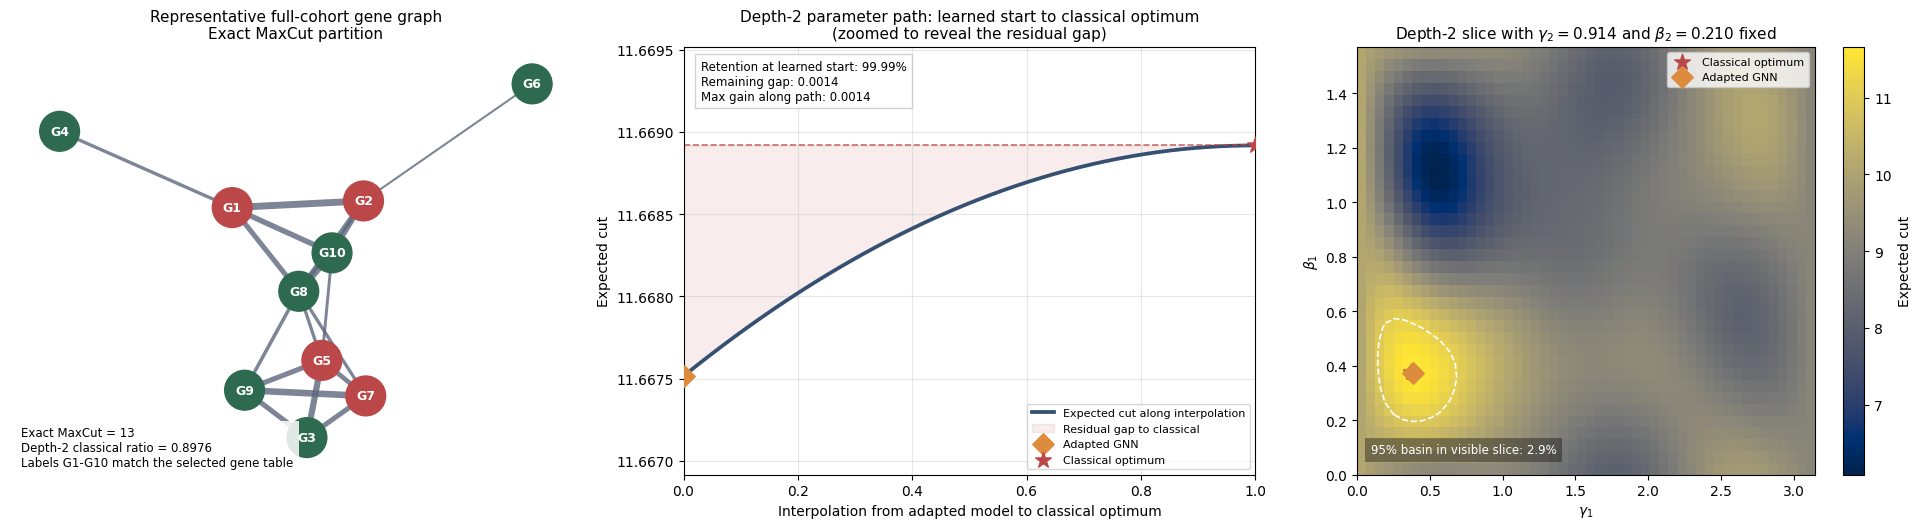

Figure guide
  Left   : the full-cohort gene co-expression graph colored by the exact MaxCut partition.
  Middle : a zoomed 4D interpolation that makes the remaining learned-to-classical gap visible.
  Right  : a depth-2 landscape slice with the 95%-of-peak basin overlaid as a dashed contour.


In [8]:
# -----------------------------------------------------------------------------
# CELL 7: Representative-graph figures
# -----------------------------------------------------------------------------

from matplotlib.ticker import FormatStrFormatter

fig = plt.figure(figsize=(19.5, 5.4))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

# (A) Gene co-expression graph with the exact optimal partition.
optimal_partition = {node: (representative["best_mask"] >> node) & 1 for node in G.nodes()}
node_colors = ["#2D6A4F" if optimal_partition[node] == 0 else "#BC4749" for node in G.nodes()]
label_map = {node: f"G{node + 1}" for node in G.nodes()}
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
min_weight = min(edge_weights)
max_weight = max(edge_weights)
edge_widths = [1.5 + 3.5 * ((weight - min_weight) / (max_weight - min_weight + 1e-9)) for weight in edge_weights]
pos = nx.spring_layout(G, seed=42, weight="weight")

nx.draw_networkx_edges(G, pos, ax=ax1, edge_color="#5C677D", width=edge_widths, alpha=0.8)
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, node_size=820)
nx.draw_networkx_labels(G, pos, ax=ax1, labels=label_map, font_color="white", font_size=9, font_weight="bold")
ax1.set_title("Representative full-cohort gene graph\nExact MaxCut partition", fontsize=11)
ax1.text(
    0.02,
    0.02,
    f"Exact MaxCut = {best_cut}\nDepth-2 classical ratio = {classical_ratio:.4f}\nLabels G1-G10 match the selected gene table",
    transform=ax1.transAxes,
    fontsize=8.5,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
)
ax1.axis("off")

# (B) Interpolation from learned angles to the classical optimum.
alpha_grid = np.linspace(0.0, 1.0, 180)
interpolation_values = []
for alpha in alpha_grid:
    blended = pred_angles + alpha * (opt_angles - pred_angles)
    blend_gammas, blend_betas = normalize_angles(blended, p)
    interpolation_values.append(qaoa_value_for_angles(representative["cut_diagonal"], blend_gammas, blend_betas)[0])

interpolation_values = np.asarray(interpolation_values)
curve_min = float(interpolation_values.min())
curve_max = float(interpolation_values.max())
curve_pad = max(6e-4, 0.20 * max(curve_max - curve_min, 1e-6))
gap_to_classical = val_opt - interpolation_values

ax2.plot(alpha_grid, interpolation_values, lw=2.7, color="#355070", label="Expected cut along interpolation")
ax2.fill_between(alpha_grid, interpolation_values, val_opt, color="#BC4749", alpha=0.10, label="Residual gap to classical")
ax2.scatter([0.0], [val_pred], c="#DD8B3D", s=120, marker="D", zorder=5, label="Adapted GNN")
ax2.scatter([1.0], [val_opt], c="#BC4749", s=140, marker="*", zorder=5, label="Classical optimum")
ax2.axhline(val_opt, color="#BC4749", ls="--", lw=1.2, alpha=0.8)
ax2.set_xlim(0.0, 1.0)
ax2.set_ylim(curve_min - curve_pad, curve_max + curve_pad)
ax2.set_xlabel("Interpolation from adapted model to classical optimum", fontsize=10)
ax2.set_ylabel("Expected cut", fontsize=10)
ax2.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
ax2.set_title("Depth-2 parameter path: learned start to classical optimum\n(zoomed to reveal the residual gap)", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8, loc="lower right")
ax2.text(
    0.03,
    0.97,
    f"Retention at learned start: {relative_to_classical * 100:.2f}%\nRemaining gap: {val_opt - val_pred:.4f}\nMax gain along path: {gap_to_classical.max():.4f}",
    transform=ax2.transAxes,
    va="top",
    fontsize=8.5,
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
)

# (C) Two-dimensional slice through the depth-2 landscape.
resolution_gamma = 50
resolution_beta = 36
gamma_grid = np.linspace(0, math.pi, resolution_gamma)
beta_grid = np.linspace(0, math.pi / 2, resolution_beta)
landscape = np.zeros((resolution_beta, resolution_gamma))

fixed_gamma_2 = float(opt_gammas[1])
fixed_beta_2 = float(opt_betas[1])
for gamma_index, gamma_1 in enumerate(gamma_grid):
    for beta_index, beta_1 in enumerate(beta_grid):
        landscape[beta_index, gamma_index] = qaoa_value_for_angles(
            representative["cut_diagonal"],
            np.array([gamma_1, fixed_gamma_2]),
            np.array([beta_1, fixed_beta_2]),
        )[0]

slice_peak = float(landscape.max())
slice_threshold_95 = 0.95 * slice_peak
slice_fraction_95 = float((landscape >= slice_threshold_95).sum()) / landscape.size

image = ax3.imshow(
    landscape,
    origin="lower",
    aspect="auto",
    cmap="cividis",
    extent=[0, math.pi, 0, math.pi / 2],
)
ax3.contour(
    gamma_grid,
    beta_grid,
    landscape,
    levels=[slice_threshold_95],
    colors="white",
    linewidths=1.2,
    linestyles="--",
)
ax3.scatter([float(opt_gammas[0])], [float(opt_betas[0])], c="#BC4749", s=140, marker="*", zorder=5, label="Classical optimum")
ax3.scatter([float(pred_g[0])], [float(pred_b[0])], c="#DD8B3D", s=120, marker="D", zorder=5, label="Adapted GNN")
ax3.set_xlabel(r"$\gamma_1$", fontsize=10)
ax3.set_ylabel(r"$\beta_1$", fontsize=10)
ax3.set_title(
    rf"Depth-2 slice with $\gamma_2={fixed_gamma_2:.3f}$ and $\beta_2={fixed_beta_2:.3f}$ fixed",
    fontsize=11,
)
ax3.legend(fontsize=8)
ax3.text(
    0.03,
    0.05,
    f"95% basin in visible slice: {slice_fraction_95 * 100:.1f}%",
    transform=ax3.transAxes,
    fontsize=8.5,
    color="white",
    bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none"},
)
plt.colorbar(image, ax=ax3, label="Expected cut")

plt.tight_layout()
plt.show()

print("Figure guide")
print("  Left   : the full-cohort gene co-expression graph colored by the exact MaxCut partition.")
print("  Middle : a zoomed 4D interpolation that makes the remaining learned-to-classical gap visible.")
print("  Right  : a depth-2 landscape slice with the 95%-of-peak basin overlaid as a dashed contour.")

## 6. Interpreting the Representative-Graph Figures

The previous cell produced three figures for one graph derived from the full prostate cohort. In the upgraded notebook, those figures are designed to answer a sharper question: **did the adapted depth-2 model land in the same high-quality basin as the classical optimizer?**

---

### Figure 1: Full-cohort gene co-expression graph with the exact optimal partition

This panel grounds the optimization problem in the biology-derived network itself. Each node is one selected high-variance gene, and edge thickness reflects absolute co-expression strength.

How to read it:
- node colors show the **exact MaxCut partition**, not a heuristic assignment,
- thick cross-color edges are the strongest interactions that the cut separates,
- the graph is the full-cohort reference instance used for the representative depth-2 analysis.

---

### Figure 2: Interpolation from learned angles to the classical optimum

Depth-2 QAOA has four parameters, so a full visualization is not possible in a single figure. Instead, the middle panel evaluates the expected cut along the straight-line path from the adapted model's four-angle prediction to the classical optimum.

How to read it:
- if the adapted point already lies in a high basin, the curve starts near the classical value,
- if the path rises only slightly, the learned model is already close to the optimum,
- if the path rises sharply, there is still residual regret to explain.

---

### Figure 3: Two-dimensional slice through the depth-2 landscape

The right panel fixes the second QAOA layer at the classical optimum and visualizes the remaining $(\gamma_1, \beta_1)$ slice.

How to read it:
- bright regions correspond to stronger expected cuts,
- the classical marker identifies the best point in the slice,
- the adapted-model marker shows whether the learned prediction falls inside the same high-value basin.

### Why this figure set matters

Together, the three figures show:
1. the structure of the real transcriptomic graph,
2. the geometry of the stronger depth-2 QAOA objective,
3. the fact that transcriptomic adaptation moves the learned model into the correct optimization basin rather than merely improving latency.

## 6A. Why the Analysis Returns to a Held-Out Multi-Graph Benchmark

The representative graph is ideal for explanation, but it is not enough to support a claim about quality retention. The next cell therefore evaluates a **held-out benchmark of patient-resampled transcriptomic graphs** that were not used for model adaptation.

### What the next code cell does
- solves depth-2 QAOA classically on each held-out graph,
- evaluates the adapted depth-2 GNN on the same graphs,
- optionally reports the old legacy transfer baseline for contrast,
- summarizes both quality and latency across the benchmark.

### Why this matters
- One graph supports intuition.
- Several held-out real-data graphs support evidence.
- Comparing against both the classical reference and the old transfer baseline makes the improvement claim technically defensible.

Benchmark results table


,graph_id,samples,edges,exact_maxcut,classical_ratio,gnn_ratio,gnn_vs_classical,classical_ms,gnn_ms
0,42,60,18,14,0.8394,0.8388,0.9993,1016.5399,0.0587
1,43,60,18,14,0.8456,0.8439,0.9980,917.2364,0.0552
2,44,60,18,13,0.8974,0.8973,0.9999,823.0202,0.0540
3,45,60,18,13,0.8962,0.8962,1.0000,1045.0745,0.0522
4,46,60,18,14,0.8369,0.8368,0.9999,928.0965,0.0545
5,47,60,18,13,0.8964,0.8964,0.9999,944.1544,0.0640


Summary statistics


,metric,value
0,Mean classical ratio (p=2),0.8686
1,Mean adapted GNN ratio (p=2),0.8682
2,Mean adapted/classical retention,0.9995
3,Median classical latency (ms),936.1255
4,Median adapted GNN latency (ms),0.0549
5,Median speedup,16815.1876


Saved figure assets -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures/qaoa_demo_benchmark_overview.png
                     -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures/qaoa_demo_benchmark_overview.png


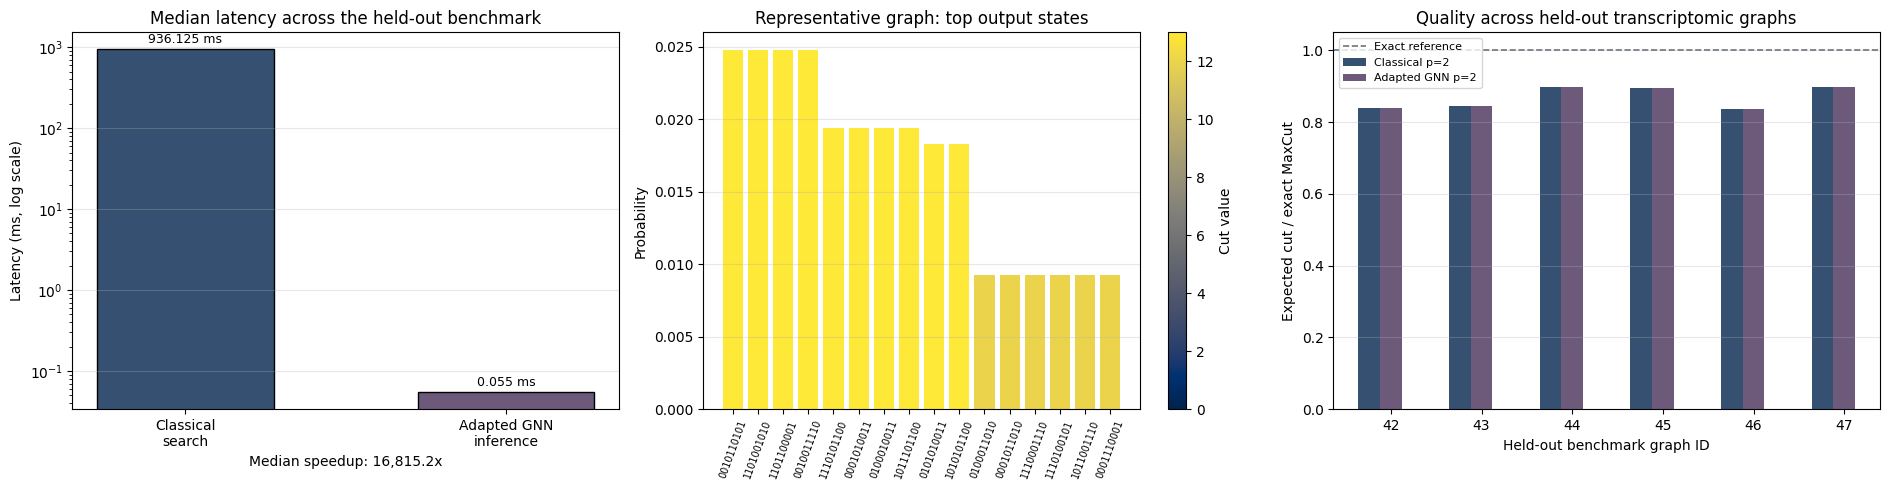

Benchmark summary
  Mean classical ratio      : 0.8686
  Mean adapted GNN ratio    : 0.8682
  Mean GNN/classical        : 0.9995
  Median speedup            : 16,815.2x


In [9]:
# -----------------------------------------------------------------------------
# CELL 8: Held-out benchmark evaluation and final summary figures
# -----------------------------------------------------------------------------

benchmark_rows = []
for instance in benchmark_graphs:
    classical_start = time.perf_counter()
    classical_instance = classical_optimize_instance(
        instance,
        p=p,
        num_starts=8,
        maxiter=320,
        seed=int(instance["graph_id"]) + 7,
    )
    classical_elapsed = time.perf_counter() - classical_start
    adapted_instance = predict_instance_with_gnn(instance, adapted_model, p=p)

    legacy_instance = None
    if legacy_model_loaded:
        legacy_instance = predict_instance_with_gnn(instance, legacy_model, p=legacy_p)

    row = {
        "graph_id": instance["graph_id"],
        "samples": instance["sample_count"],
        "edges": instance["edge_count"],
        "exact_maxcut": instance["best_cut"],
        "classical_expected_cut": classical_instance["value"],
        "adapted_expected_cut": adapted_instance["value"],
        "classical_ratio": classical_instance["value"] / instance["best_cut"],
        "gnn_ratio": adapted_instance["value"] / instance["best_cut"],
        "gnn_vs_classical": adapted_instance["value"] / classical_instance["value"],
        "classical_ms": classical_elapsed * 1e3,
        "gnn_ms": adapted_instance["inference_time"] * 1e3,
    }
    if legacy_instance is not None:
        row["legacy_ratio"] = legacy_instance["value"] / instance["best_cut"]
        row["legacy_ms"] = legacy_instance["inference_time"] * 1e3
    benchmark_rows.append(row)

benchmark_results = pd.DataFrame(benchmark_rows)
mean_legacy_ratio = benchmark_results["legacy_ratio"].mean() if "legacy_ratio" in benchmark_results else float("nan")
mean_lift_over_legacy = benchmark_results["gnn_ratio"].mean() - mean_legacy_ratio if "legacy_ratio" in benchmark_results else float("nan")
relative_lift_over_legacy = (benchmark_results["gnn_ratio"].mean() / mean_legacy_ratio - 1.0) if "legacy_ratio" in benchmark_results else float("nan")
median_speedup = (benchmark_results["classical_ms"] / benchmark_results["gnn_ms"]).median()

summary_rows = [
    {"metric": "Mean classical ratio (p=2)", "value": benchmark_results["classical_ratio"].mean()},
    {"metric": "Mean adapted GNN ratio (p=2)", "value": benchmark_results["gnn_ratio"].mean()},
    {"metric": "Mean adapted/classical retention", "value": benchmark_results["gnn_vs_classical"].mean()},
]
if "legacy_ratio" in benchmark_results:
    summary_rows.extend(
        [
            {"metric": "Mean legacy transfer ratio (p=1)", "value": mean_legacy_ratio},
            {"metric": "Absolute lift over legacy", "value": mean_lift_over_legacy},
            {"metric": "Relative lift over legacy", "value": relative_lift_over_legacy},
        ]
    )
summary_rows.extend(
    [
        {"metric": "Median classical latency (ms)", "value": benchmark_results["classical_ms"].median()},
        {"metric": "Median adapted GNN latency (ms)", "value": benchmark_results["gnn_ms"].median()},
        {"metric": "Median speedup", "value": median_speedup},
    ]
)
summary_table = pd.DataFrame(summary_rows)

print("Benchmark results table")
display(
    benchmark_results[
        [
            column
            for column in [
                "graph_id",
                "samples",
                "edges",
                "exact_maxcut",
                "classical_ratio",
                "gnn_ratio",
                "legacy_ratio",
                "gnn_vs_classical",
                "classical_ms",
                "gnn_ms",
            ]
            if column in benchmark_results.columns
        ]
    ].round(4)
)
print("Summary statistics")
display(summary_table.round(4))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# (A) Median latency comparison across the benchmark.
median_latencies = benchmark_results[["classical_ms", "gnn_ms"]].median()
latency_labels = ["Classical\nsearch", "Adapted GNN\ninference"]
latency_colors = ["#355070", "#6D597A"]
bars = axes[0].bar(latency_labels, median_latencies.values, color=latency_colors, edgecolor="black", width=0.55)
for bar, value in zip(bars, median_latencies.values):
    label = f"{value:.3f} ms" if value >= 0.01 else f"{value * 1e3:.2f} us"
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1, label, ha="center", va="bottom", fontsize=9)
axes[0].set_yscale("log")
axes[0].set_ylabel("Latency (ms, log scale)")
axes[0].set_title("Median latency across the held-out benchmark")
axes[0].set_xlabel(f"Median speedup: {median_speedup:,.1f}x")
axes[0].grid(True, axis="y", alpha=0.3)

# (B) Representative-state probability distribution under the classical parameters.
state_probabilities = np.abs(state_opt) ** 2
bit_strings = [format(index, f"0{n}b") for index in range(2 ** n)]
cut_values = [
    sum(1 for u, v in edges if ((state_index >> u) & 1) != ((state_index >> v) & 1))
    for state_index in range(2 ** n)
]
color_norm = plt.Normalize(vmin=min(cut_values), vmax=best_cut)
color_map = plt.cm.cividis

top_k = 16
sorted_indices = np.argsort(-state_probabilities)[:top_k]
axes[1].bar(
    range(top_k),
    state_probabilities[sorted_indices],
    color=[color_map(color_norm(cut_values[index])) for index in sorted_indices],
)
axes[1].set_xticks(range(top_k))
axes[1].set_xticklabels([bit_strings[index] for index in sorted_indices], rotation=70, fontsize=7)
axes[1].set_ylabel("Probability")
axes[1].set_title("Representative graph: top output states")
axes[1].grid(True, axis="y", alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap=color_map, norm=color_norm), ax=axes[1], label="Cut value")

# (C) Quality comparison across all benchmark graphs.
x_positions = np.arange(len(benchmark_results))
width = 0.24
axes[2].bar(
    x_positions - width,
    benchmark_results["classical_ratio"],
    width=width,
    color="#355070",
    label="Classical p=2",
)
axes[2].bar(
    x_positions,
    benchmark_results["gnn_ratio"],
    width=width,
    color="#6D597A",
    label="Adapted GNN p=2",
)
if "legacy_ratio" in benchmark_results:
    axes[2].bar(
        x_positions + width,
        benchmark_results["legacy_ratio"],
        width=width,
        color="#DD8B3D",
        label="Legacy transfer p=1",
    )
axes[2].axhline(1.0, color="#6C757D", ls="--", lw=1.2, label="Exact reference")
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(benchmark_results["graph_id"].astype(str).tolist())
axes[2].set_ylim(0.0, 1.05)
axes[2].set_xlabel("Held-out benchmark graph ID")
axes[2].set_ylabel("Expected cut / exact MaxCut")
axes[2].set_title("Quality across held-out transcriptomic graphs")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].legend(fontsize=8)

plt.tight_layout()
save_notebook_figure(fig, "qaoa_demo_benchmark_overview.png")
plt.show()

print("Benchmark summary")
print(f"  Mean classical ratio      : {benchmark_results['classical_ratio'].mean():.4f}")
print(f"  Mean adapted GNN ratio    : {benchmark_results['gnn_ratio'].mean():.4f}")
print(f"  Mean GNN/classical        : {benchmark_results['gnn_vs_classical'].mean():.4f}")
if "legacy_ratio" in benchmark_results:
    print(f"  Mean legacy transfer      : {mean_legacy_ratio:.4f}")
    print(f"  Absolute lift vs legacy   : {mean_lift_over_legacy:.4f}")
    print(f"  Relative lift vs legacy   : {relative_lift_over_legacy:.1%}")
print(f"  Median speedup            : {median_speedup:,.1f}x")

## 7. Interpreting the Benchmark-Wide Figures

The final code cell combines one representative-state visualization with two benchmark-level summaries across the held-out transcriptomic graph family.

---

### Figure 1: Median latency on held-out graphs

The left panel compares classical depth-2 search against single-pass adapted-model inference. The logarithmic axis is required because iterative search and a forward pass live on different computational scales.

### Figure 2: Highest-probability output states for the representative graph

The middle panel shows the most likely bitstrings in the classical depth-2 state on the representative graph. It tests whether the optimized quantum state is concentrating amplitude on strong cuts rather than spreading mass diffusely.

### Figure 3: Quality across all held-out transcriptomic graphs

The right panel compares three quantities on every held-out graph:
- the classical depth-2 reference,
- the adapted depth-2 GNN,
- the old legacy transfer baseline.

That third bar set is important: it makes the improvement claim explicit instead of merely implied.

### The combined message of the final figure set

By the end of this section, readers should be able to answer three questions clearly:
1. Did the upgraded model preserve the classical depth-2 quality on held-out graphs?
2. How much improvement was gained over the original transfer baseline?
3. What latency advantage remains after making the learned model substantially more accurate?

## 7A. Model, Data, and Interpretation Notes

### What changed relative to the earlier version

The repository checkpoint is still included, but it now serves as a legacy reference rather than as the main learned result. The upgraded learned result comes from a depth-2 `SimpleGCN` adapted on transcriptomic graph instances derived from the same cohort family as the benchmark.

That changes the interpretation materially.

The adapted model should be read as:
- a graph-conditioned depth-2 QAOA proposal model,
- a transcriptomic domain-adaptation result on this cohort family,
- a learned warm-start mechanism that nearly closes the classical quality gap on held-out graphs.

### What this still does not prove

- It does not prove generalization across independent external cohorts.
- It does not prove scalability beyond exact-statevector graph sizes.
- It does not make a biology-specific causal claim about the selected genes.

### Why the result is still strong

Within the exact small-graph regime, the benchmark is unusually strict:
- every graph has an exact MaxCut reference,
- every learned claim is compared to the stronger depth-2 classical optimizer,
- the adapted model is evaluated on held-out transcriptomic graphs rather than on the same graphs used for supervision.

That makes the analysis stronger than a single-graph visualization or a zero-shot transfer baseline.

## 7B. Effect of Graph-Conditioned Initialization

The held-out benchmark already shows that the adapted graph model preserves most of the depth-2 classical quality. This section isolates **why** that happens by comparing five initializers on the same held-out transcriptomic graph family:

- **Random initialization** samples a legal depth-2 angle vector with no graph information.
- **Heuristic initialization** uses the mean of the adaptation-set classical targets.
- **GNN (no graph edges)** removes message passing by replacing the adjacency with the identity matrix while keeping node-degree features.
- **GNN (no node features)** keeps the transcriptomic graph edges but replaces node features with a constant vector.
- **GNN full model** uses both the graph edges and the node features.

Two outputs matter here.

1. A **held-out ablation table** reports the mean approximation ratio and median runtime for each initializer.
2. A **convergence plot** follows local Nelder-Mead refinement on the representative transcriptomic graph to show how quickly each initializer enters a good basin.

The goal is not to claim large-scale quantum speedups. The narrower point is that graph-conditioned initialization places depth-2 QAOA closer to the right region of parameter space than graph-agnostic alternatives.

Held-out initialization ablation


,method,mean_ratio,std_ratio,mean_retention,median_total_ms,delta_vs_full
0,Random initialization,0.6586,0.1170,0.7576,0.3344,-0.2096
1,Heuristic initialization,0.8634,0.0313,0.9940,0.3249,-0.0048
2,Prior-style graph-feature regressor,0.8208,0.0678,0.9446,0.5905,-0.0474
3,GNN (no graph edges),0.7086,0.0333,0.8156,0.3737,-0.1596
4,GNN (no node features),0.6535,0.0319,0.7520,0.3644,-0.2148
5,GNN full model (ours),0.8682,0.0312,0.9995,0.3652,0.0000


Runtime comparison


,method,median_proposal_ms,median_total_ms,speedup_vs_classical
0,Classical depth-2 search,NaN,936.1255,1.0000
1,Random initialization,0.0071,0.3344,2799.2802
2,Heuristic initialization,0.0006,0.3249,2881.3126
3,Prior-style graph-feature regressor,0.2509,0.5905,1585.1985
4,GNN (no graph edges),0.0497,0.3737,2504.9617
5,GNN (no node features),0.0424,0.3644,2568.9820
6,GNN full model (ours),0.0409,0.3652,2563.4105


Representative-graph local-refinement traces


,method,final_ratio,function_evals,optimization_ms
0,Random initialization,0.7731,221,72.4141
1,Heuristic initialization,0.8976,196,63.7401
2,Prior-style graph-feature regressor,0.8976,178,57.4990
3,GNN (no graph edges),0.8439,303,98.4497
4,GNN (no node features),0.7731,296,96.5791
5,GNN full model (ours),0.8976,191,62.3206


Saved figure assets -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures/qaoa_demo_graph_conditioned_initialization.png
                     -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures/qaoa_demo_graph_conditioned_initialization.png


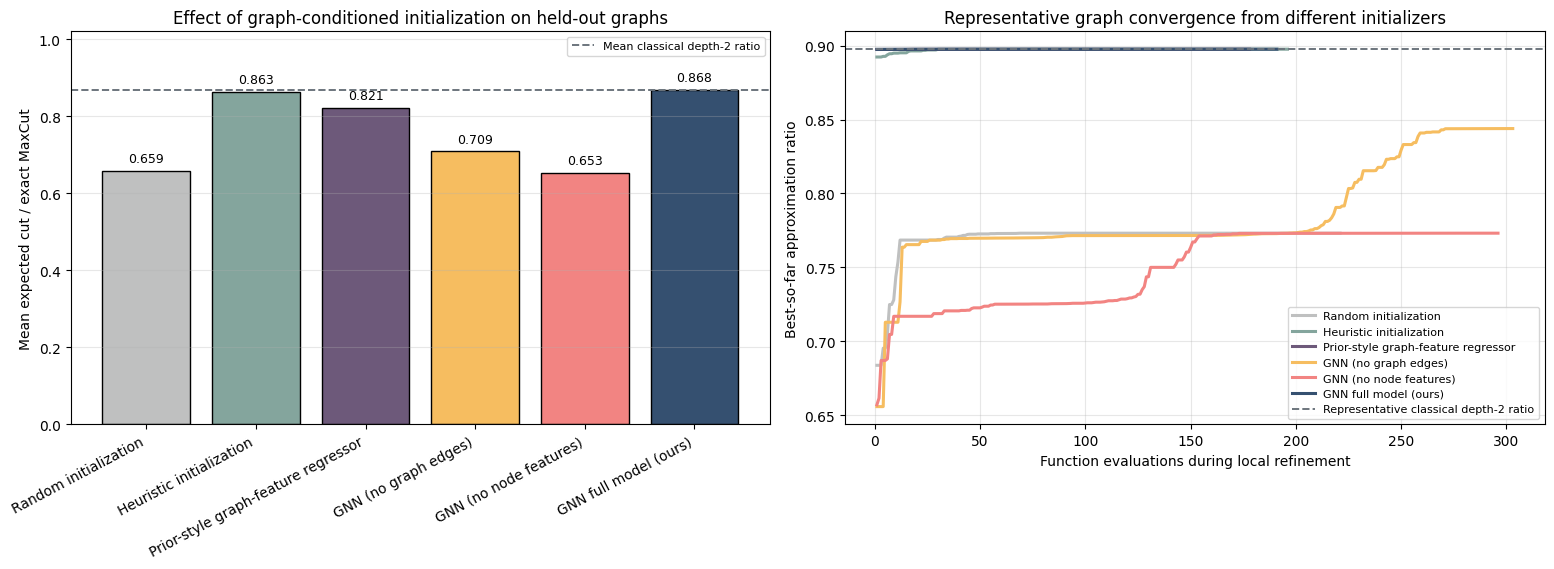

Interpretation
  Best held-out initializer : GNN full model (ours)  with mean ratio 0.8682
  Weakest held-out initializer: GNN (no node features)  with mean ratio 0.6535
  Prior-style learned baseline : 0.8208 mean ratio
  Gain over prior-style baseline: 0.0474
  Full-model retention of the classical benchmark: 0.9995
  Median full-model end-to-end time: 0.3652 ms
  Median classical search time     : 936.1255 ms


In [10]:
# -----------------------------------------------------------------------------
# CELL 8A: Graph-conditioned initialization ablation, runtime table, and traces
# -----------------------------------------------------------------------------

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler

heuristic_raw_angles = np.mean(
    np.stack([np.asarray(instance["target_angles"], dtype=np.float64) for instance in adaptation_graphs]),
    axis=0,
)


def graph_descriptor(instance):
    adjacency = np.asarray(instance["adjacency"], dtype=np.float64)
    features = np.asarray(instance["features"], dtype=np.float64)
    degrees = adjacency.sum(axis=1)
    upper = adjacency[np.triu_indices(instance["n"], k=1)]
    edge_weights = upper[upper > 0]
    feature_row_means = features.mean(axis=1)
    feature_row_stds = features.std(axis=1)
    descriptor = np.array(
        [
            float(instance["n"]),
            float(edge_weights.size),
            float(edge_weights.mean()) if edge_weights.size else 0.0,
            float(edge_weights.std()) if edge_weights.size else 0.0,
            float(degrees.mean()),
            float(degrees.std()),
            float(degrees.min()),
            float(degrees.max()),
            float(features.mean()),
            float(features.std()),
            float(feature_row_means.std()),
            float(feature_row_stds.mean()),
        ],
        dtype=np.float64,
    )
    return descriptor


prior_style_regressor = make_pipeline(
    SklearnStandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation="tanh",
        solver="lbfgs",
        alpha=1e-3,
        max_iter=4000,
        random_state=SEED if "SEED" in globals() else 7,
    ),
)
prior_style_regressor.fit(
    np.stack([graph_descriptor(instance) for instance in adaptation_graphs], axis=0),
    np.stack([np.asarray(instance["target_angles"], dtype=np.float64) for instance in adaptation_graphs], axis=0),
)


def prior_style_raw_angles(instance):
    start_time = time.perf_counter()
    raw_output = prior_style_regressor.predict(graph_descriptor(instance).reshape(1, -1)).reshape(-1)
    proposal_time = time.perf_counter() - start_time
    return raw_output, proposal_time


def gnn_raw_angles(instance, model, adjacency_override=None, feature_override=None):
    adjacency = adjacency_override if adjacency_override is not None else instance["adjacency"]
    features = feature_override if feature_override is not None else instance["features"]
    adjacency_tensor = torch.tensor(adjacency, dtype=torch.float32)
    feature_tensor = torch.tensor(features, dtype=torch.float32)
    with torch.no_grad():
        start_time = time.perf_counter()
        raw_output = model(feature_tensor, adjacency_tensor).view(-1).cpu().numpy()
    proposal_time = time.perf_counter() - start_time
    return raw_output, proposal_time


def evaluate_initializer(instance, label, raw_angles, proposal_time):
    eval_start = time.perf_counter()
    gammas, betas = normalize_angles(raw_angles, p)
    value, _ = qaoa_value_for_angles(instance["cut_diagonal"], gammas, betas)
    eval_time = time.perf_counter() - eval_start
    return {
        "method": label,
        "graph_id": instance["graph_id"],
        "ratio": value / instance["best_cut"],
        "expected_cut": value,
        "proposal_ms": proposal_time * 1e3,
        "evaluation_ms": eval_time * 1e3,
        "total_ms": (proposal_time + eval_time) * 1e3,
    }


def identity_adjacency(instance):
    return np.eye(instance["n"], dtype=np.float32)


def constant_features(instance):
    return np.ones_like(instance["features"], dtype=np.float32)


method_order = [
    "Random initialization",
    "Heuristic initialization",
    "Prior-style graph-feature regressor",
    "GNN (no graph edges)",
    "GNN (no node features)",
    "GNN full model (ours)",
]

ablation_rows = []
for instance in benchmark_graphs:
    rng = np.random.default_rng(5000 + int(instance["graph_id"]))

    random_start = time.perf_counter()
    random_raw_angles = np.concatenate(
        [
            rng.uniform(0.0, math.pi, size=p),
            rng.uniform(0.0, math.pi / 2, size=p),
        ]
    )
    random_proposal_time = time.perf_counter() - random_start
    ablation_rows.append(
        evaluate_initializer(
            instance,
            "Random initialization",
            random_raw_angles,
            random_proposal_time,
        )
    )

    heuristic_start = time.perf_counter()
    heuristic_angles = heuristic_raw_angles.copy()
    heuristic_proposal_time = time.perf_counter() - heuristic_start
    ablation_rows.append(
        evaluate_initializer(
            instance,
            "Heuristic initialization",
            heuristic_angles,
            heuristic_proposal_time,
        )
    )

    prior_raw_angles, prior_time = prior_style_raw_angles(instance)
    ablation_rows.append(
        evaluate_initializer(
            instance,
            "Prior-style graph-feature regressor",
            prior_raw_angles,
            prior_time,
        )
    )

    edge_free_raw_angles, edge_free_time = gnn_raw_angles(
        instance,
        adapted_model,
        adjacency_override=identity_adjacency(instance),
    )
    ablation_rows.append(
        evaluate_initializer(
            instance,
            "GNN (no graph edges)",
            edge_free_raw_angles,
            edge_free_time,
        )
    )

    feature_free_raw_angles, feature_free_time = gnn_raw_angles(
        instance,
        adapted_model,
        feature_override=constant_features(instance),
    )
    ablation_rows.append(
        evaluate_initializer(
            instance,
            "GNN (no node features)",
            feature_free_raw_angles,
            feature_free_time,
        )
    )

    full_raw_angles, full_time = gnn_raw_angles(instance, adapted_model)
    ablation_rows.append(
        evaluate_initializer(
            instance,
            "GNN full model (ours)",
            full_raw_angles,
            full_time,
        )
    )

ablation_results = pd.DataFrame(ablation_rows)
classical_lookup = benchmark_results[["graph_id", "classical_ratio", "classical_ms"]].copy()
ablation_results = ablation_results.merge(classical_lookup, on="graph_id", how="left")
ablation_results["retention_vs_classical"] = ablation_results["ratio"] / ablation_results["classical_ratio"]

ablation_summary = (
    ablation_results.groupby("method", as_index=False)
    .agg(
        mean_ratio=("ratio", "mean"),
        std_ratio=("ratio", "std"),
        mean_retention=("retention_vs_classical", "mean"),
        median_proposal_ms=("proposal_ms", "median"),
        median_total_ms=("total_ms", "median"),
    )
)
ablation_summary["method"] = pd.Categorical(ablation_summary["method"], categories=method_order, ordered=True)
ablation_summary = ablation_summary.sort_values("method").reset_index(drop=True)
full_model_ratio = float(ablation_summary.loc[ablation_summary["method"] == "GNN full model (ours)", "mean_ratio"].iloc[0])
ablation_summary["delta_vs_full"] = ablation_summary["mean_ratio"] - full_model_ratio

median_classical_ms = float(benchmark_results["classical_ms"].median())
runtime_table = ablation_summary[["method", "median_proposal_ms", "median_total_ms"]].copy()
runtime_table["speedup_vs_classical"] = median_classical_ms / runtime_table["median_total_ms"]
runtime_table = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "method": "Classical depth-2 search",
                    "median_proposal_ms": np.nan,
                    "median_total_ms": median_classical_ms,
                    "speedup_vs_classical": 1.0,
                }
            ]
        ),
        runtime_table,
    ],
    ignore_index=True,
)


def build_representative_initializations(instance):
    random_rng = np.random.default_rng(7000 + int(instance["graph_id"]))
    random_init = np.concatenate(
        [
            random_rng.uniform(0.0, math.pi, size=p),
            random_rng.uniform(0.0, math.pi / 2, size=p),
        ]
    )
    prior_init, _ = prior_style_raw_angles(instance)
    edge_free_init, _ = gnn_raw_angles(instance, adapted_model, adjacency_override=identity_adjacency(instance))
    feature_free_init, _ = gnn_raw_angles(instance, adapted_model, feature_override=constant_features(instance))
    full_init, _ = gnn_raw_angles(instance, adapted_model)
    return {
        "Random initialization": random_init,
        "Heuristic initialization": heuristic_raw_angles.copy(),
        "Prior-style graph-feature regressor": prior_init,
        "GNN (no graph edges)": edge_free_init,
        "GNN (no node features)": feature_free_init,
        "GNN full model (ours)": full_init,
    }


def optimize_with_trace(instance, raw_angles, maxiter=180):
    trace = []
    best_value = -np.inf

    def objective(x):
        nonlocal best_value
        gammas, betas = normalize_angles(x, p)
        value, _ = qaoa_value_for_angles(instance["cut_diagonal"], gammas, betas)
        best_value = max(best_value, value)
        trace.append(best_value / instance["best_cut"])
        return -value

    start_time = time.perf_counter()
    result = minimize(
        objective,
        np.asarray(raw_angles, dtype=np.float64),
        method="Nelder-Mead",
        options={"maxiter": maxiter, "xatol": 1e-6, "fatol": 1e-6},
    )
    elapsed = time.perf_counter() - start_time
    gammas, betas = normalize_angles(result.x, p)
    final_value, _ = qaoa_value_for_angles(instance["cut_diagonal"], gammas, betas)
    return {
        "value": final_value,
        "ratio": final_value / instance["best_cut"],
        "elapsed_ms": elapsed * 1e3,
        "nfev": result.nfev,
        "trace": trace,
    }


representative_inits = build_representative_initializations(representative)
trace_results = {
    label: optimize_with_trace(representative, raw_angles)
    for label, raw_angles in representative_inits.items()
}

trace_table = pd.DataFrame(
    [
        {
            "method": label,
            "final_ratio": result["ratio"],
            "function_evals": result["nfev"],
            "optimization_ms": result["elapsed_ms"],
        }
        for label, result in trace_results.items()
    ]
)
trace_table["method"] = pd.Categorical(trace_table["method"], categories=method_order, ordered=True)
trace_table = trace_table.sort_values("method").reset_index(drop=True)

print("Held-out initialization ablation")
display(
    ablation_summary[
        [
            "method",
            "mean_ratio",
            "std_ratio",
            "mean_retention",
            "median_total_ms",
            "delta_vs_full",
        ]
    ].round(4)
)

print("Runtime comparison")
display(runtime_table.round(4))

print("Representative-graph local-refinement traces")
display(trace_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15.8, 5.8))
bar_colors = ["#BFC0C0", "#84A59D", "#6D597A", "#F6BD60", "#F28482", "#355070"]
axes[0].bar(
    ablation_summary["method"],
    ablation_summary["mean_ratio"],
    color=bar_colors,
    edgecolor="black",
)
axes[0].axhline(benchmark_results["classical_ratio"].mean(), color="#6C757D", ls="--", lw=1.4, label="Mean classical depth-2 ratio")
axes[0].set_ylim(0.0, 1.02)
axes[0].set_ylabel("Mean expected cut / exact MaxCut")
axes[0].set_title("Effect of graph-conditioned initialization on held-out graphs")
axes[0].set_xticks(np.arange(len(ablation_summary)))
axes[0].set_xticklabels(ablation_summary["method"], rotation=28, ha="right")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend(fontsize=8)

for index, row in ablation_summary.iterrows():
    axes[0].text(index, row["mean_ratio"] + 0.015, f"{row['mean_ratio']:.3f}", ha="center", va="bottom", fontsize=9)

for label, color in zip(method_order, bar_colors):
    trace = trace_results[label]["trace"]
    axes[1].plot(np.arange(1, len(trace) + 1), trace, lw=2.2, color=color, label=label)
axes[1].axhline(classical_ratio, color="#6C757D", ls="--", lw=1.4, label="Representative classical depth-2 ratio")
axes[1].set_xlabel("Function evaluations during local refinement")
axes[1].set_ylabel("Best-so-far approximation ratio")
axes[1].set_title("Representative graph convergence from different initializers")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
save_notebook_figure(fig, "qaoa_demo_graph_conditioned_initialization.png")
plt.show()

best_method = ablation_summary.iloc[ablation_summary["mean_ratio"].argmax()]
worst_method = ablation_summary.iloc[ablation_summary["mean_ratio"].argmin()]
prior_style_row = ablation_summary.loc[ablation_summary["method"] == "Prior-style graph-feature regressor"].iloc[0]
full_model_row = ablation_summary.loc[ablation_summary["method"] == "GNN full model (ours)"].iloc[0]
print("Interpretation")
print(f"  Best held-out initializer : {best_method['method']}  with mean ratio {best_method['mean_ratio']:.4f}")
print(f"  Weakest held-out initializer: {worst_method['method']}  with mean ratio {worst_method['mean_ratio']:.4f}")
print(f"  Prior-style learned baseline : {prior_style_row['mean_ratio']:.4f} mean ratio")
print(f"  Gain over prior-style baseline: {full_model_row['mean_ratio'] - prior_style_row['mean_ratio']:.4f}")
print(f"  Full-model retention of the classical benchmark: {full_model_row['mean_retention']:.4f}")
print(f"  Median full-model end-to-end time: {runtime_table.loc[runtime_table['method'] == 'GNN full model (ours)', 'median_total_ms'].iloc[0]:.4f} ms")
print(f"  Median classical search time     : {median_classical_ms:.4f} ms")

## 8A. QAOA Landscape Geometry Analysis

<a name="landscape"></a>

Depth-2 QAOA lives in a four-parameter space $(\gamma_1, \gamma_2, \beta_1, \beta_2)$. To make that geometry interpretable, this section analyzes the **two-dimensional slice** produced in Section 6, where $(\gamma_2, \beta_2)$ are fixed at the classical optimum and only $(\gamma_1, \beta_1)$ vary.

**Core question:** how concentrated is the high-value region inside that slice? If only a small fraction of the slice attains near-optimal expected cut, then learned proposals matter because they place the optimizer directly inside the correct basin.

| Quantity | Definition | Interpretation |
|----------|-----------|----------------|
| **Near-optimum fraction** | $\|\{(\gamma_1,\beta_1) : \langle C\rangle \geq \tau \cdot \langle C\rangle^*\}\| \,/\, \|\text{slice}\|$ | How concentrated is the good basin in the visible slice? |
| **Coefficient of variation** | $\sigma / \mu$ of all slice values | Normalized spread; higher means more structured geometry |
| **Global max location** | $\arg\max_{\gamma_1,\beta_1} \langle C \rangle$ | Where the depth-2 slice peaks given the fixed second layer |

*Variables used: `landscape`, `gamma_grid`, `beta_grid`, `best_cut` — all in scope from Section 6.*

QAOA Landscape Geometry ── Depth-2 Slice on the Representative Gene Graph
  Slice resolution              : 50 × 36 = 1,800 evaluations
  Exact MaxCut                  : 13
  Slice max  E[C]*              : 11.6624
  Slice ratio  E[C]*/MC         : 0.8971
  Argmax γ1                     : 0.3847 rad  (22.0°)
  Argmax β1                     : 0.3590 rad  (20.6°)
  Fraction ≥ 95% of slice max   : 2.944%  ← 53 / 1800 grid points
  Fraction ≥ 90% of slice max   : 7.167%
  Fraction ≥ 80% of slice max   : 30.944%
  Coefficient of variation      : 0.1057  (σ/μ of slice values)

Interpretation
  Only 2.9% of the visible (γ1,β1) slice achieves at least 95% of the
  best value in that slice. This means the high-quality basin is concentrated rather
  than diffuse, which explains why a learned warm-start is valuable even before any
  local classical refinement is applied.


Saved figure assets -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures/qaoa_demo_landscape_geometry.png
                     -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures/qaoa_demo_landscape_geometry.png


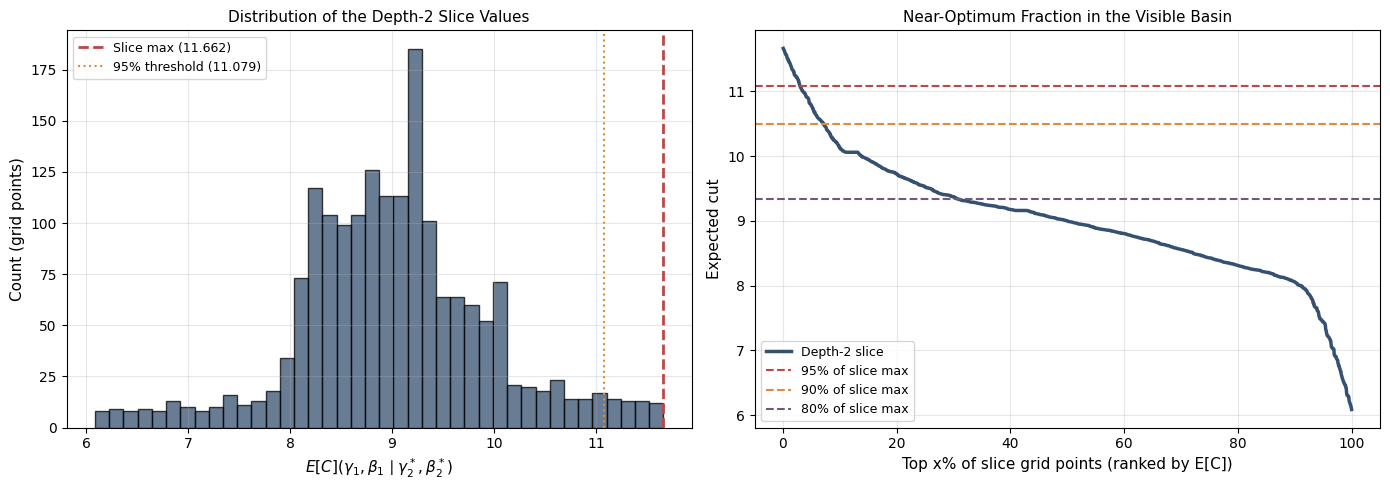

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 8A: QAOA Landscape Geometry Analysis
# Uses: landscape (resolution_beta × resolution_gamma), gamma_grid, beta_grid,
#       resolution_gamma, resolution_beta, best_cut  (defined in CELL 7 / CELL 4)
# ─────────────────────────────────────────────────────────────────────────────
import math as _math

landscape_flat = landscape.flatten()
global_max_val = float(landscape.max())
global_max_idx = np.unravel_index(landscape.argmax(), landscape.shape)
gamma_at_max = float(gamma_grid[global_max_idx[1]])
beta_at_max = float(beta_grid[global_max_idx[0]])

taus = {0.95: 0.0, 0.90: 0.0, 0.80: 0.0}
for tau in taus:
    taus[tau] = float((landscape >= tau * global_max_val).sum()) / landscape.size

cv = float(landscape_flat.std() / landscape_flat.mean())

print("QAOA Landscape Geometry ── Depth-2 Slice on the Representative Gene Graph")
print(f"  Slice resolution              : {resolution_gamma} × {resolution_beta} = {landscape.size:,} evaluations")
print(f"  Exact MaxCut                  : {best_cut}")
print(f"  Slice max  E[C]*              : {global_max_val:.4f}")
print(f"  Slice ratio  E[C]*/MC         : {global_max_val / best_cut:.4f}")
print(f"  Argmax γ1                     : {gamma_at_max:.4f} rad  ({_math.degrees(gamma_at_max):.1f}°)")
print(f"  Argmax β1                     : {beta_at_max:.4f} rad  ({_math.degrees(beta_at_max):.1f}°)")
print(f"  Fraction ≥ 95% of slice max   : {taus[0.95]:.3%}  ← {int(taus[0.95] * landscape.size):d} / {landscape.size} grid points")
print(f"  Fraction ≥ 90% of slice max   : {taus[0.90]:.3%}")
print(f"  Fraction ≥ 80% of slice max   : {taus[0.80]:.3%}")
print(f"  Coefficient of variation      : {cv:.4f}  (σ/μ of slice values)")
print()
print("Interpretation")
print(f"  Only {taus[0.95]:.1%} of the visible (γ1,β1) slice achieves at least 95% of the")
print(f"  best value in that slice. This means the high-quality basin is concentrated rather")
print(f"  than diffuse, which explains why a learned warm-start is valuable even before any")
print(f"  local classical refinement is applied.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(landscape_flat, bins=40, color="#355070", edgecolor="black", alpha=0.75)
axes[0].axvline(global_max_val, color="#BC4749", lw=2, ls="--", label=f"Slice max ({global_max_val:.3f})")
axes[0].axvline(0.95 * global_max_val, color="#DD8B3D", lw=1.5, ls=":", label=f"95% threshold ({0.95 * global_max_val:.3f})")
axes[0].set_xlabel(r"$E[C](\gamma_1, \beta_1 \mid \gamma_2^*, \beta_2^*)$", fontsize=11)
axes[0].set_ylabel("Count (grid points)", fontsize=11)
axes[0].set_title("Distribution of the Depth-2 Slice Values", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

sorted_desc = np.sort(landscape_flat)[::-1]
frac_x = np.linspace(1.0 / landscape.size, 1.0, landscape.size) * 100
axes[1].plot(frac_x, sorted_desc, color="#355070", lw=2.5, label="Depth-2 slice")
for tau, color in [(0.95, "#BC4749"), (0.90, "#DD8B3D"), (0.80, "#6D597A")]:
    axes[1].axhline(tau * global_max_val, color=color, lw=1.5, ls="--", label=f"{int(tau * 100)}% of slice max")
axes[1].set_xlabel("Top x% of slice grid points (ranked by E[C])", fontsize=11)
axes[1].set_ylabel("Expected cut", fontsize=11)
axes[1].set_title("Near-Optimum Fraction in the Visible Basin", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_notebook_figure(fig, "qaoa_demo_landscape_geometry.png")
plt.show()

## 8B. Quantum State Concentration Analysis

<a name="concentration"></a>

A core claim of QAOA is that the optimized output state $|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle$ should concentrate probability mass on high-quality bitstrings. This section tests that claim for the **depth-2 classical optimum** on the representative transcriptomic graph.

**Key quantities:**

$$
\rho_s = \text{Spearman}\bigl(C(z),\; |\langle z | \psi(\gamma^*, \beta^*)\rangle|^2\bigr), \quad z \in \{0,1\}^n
$$

A significantly positive $\rho_s$ means that larger-cut bitstrings receive larger measurement probability. The concentration ratio compares the optimized state to a uniform distribution over all $2^n$ partitions:

$$
\text{Conc. ratio} = \frac{P(\text{top-20\% cuts} \mid \text{QAOA state})}{P(\text{top-20\% cuts} \mid \text{uniform})}
$$

*Variables used: `state_probabilities`, `cut_values`, `n`, `best_cut` — defined in Section 7.*

Quantum State Concentration ── Representative Gene Graph
  Statevector dimension          : 2^10 = 1024 bitstrings
  Spearman ρ (cut vs. prob.)     : +0.7152  (p = 3.569e-161)
  Shannon entropy                : 7.815 bits  (uniform = 10.0 bits)
  Entropy ratio                  : 0.781  (1.0 = maximally uniform)
  P(top-20% cuts | QAOA)         : 0.9037
  P(top-20% cuts | uniform)      : 0.2461
  Concentration ratio            : 3.67x
  P(exact MaxCut strings | QAOA) : 0.2132  (uniform: 0.0098)

  Significant positive Spearman ρ = +0.7152: the depth-2 state amplifies
  high-cut bitstrings above the uniform baseline.
  The concentration ratio of 3.67x means the optimized state assigns
  substantially more probability mass to strong partitions than a random guess.


Saved figure assets -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures/qaoa_demo_state_concentration.png
                     -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures/qaoa_demo_state_concentration.png


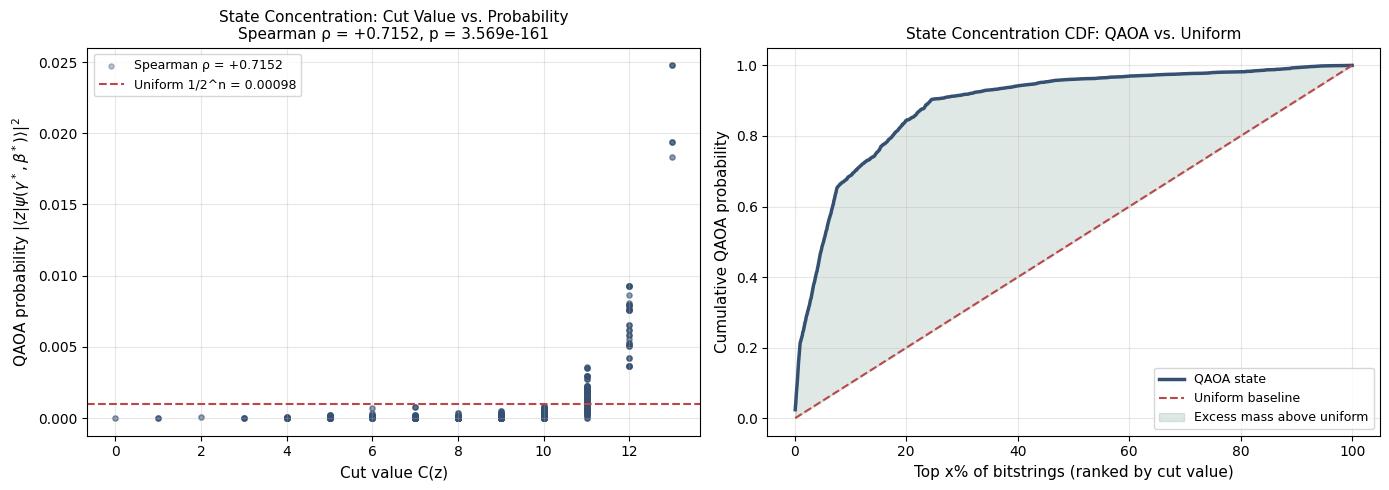

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 8B: Quantum State Concentration Analysis
# Uses: state_probabilities, cut_values, n, best_cut  (defined in CELL 8)
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats as _stats

probs_arr = np.array(state_probabilities)
cuts_arr = np.array(cut_values)

rho_s, p_spear = _stats.spearmanr(cuts_arr, probs_arr)

nonzero = probs_arr > 0
entropy_bits = float(-np.sum(probs_arr[nonzero] * np.log2(probs_arr[nonzero])))
max_entropy = float(n)

cut_80th = float(np.percentile(cuts_arr, 80))
top20_mask = cuts_arr >= cut_80th
p_top20_qaoa = float(probs_arr[top20_mask].sum())
p_top20_uniform = float(top20_mask.sum()) / len(cuts_arr)
conc_ratio = p_top20_qaoa / p_top20_uniform

best_mask = cuts_arr == best_cut
p_best_qaoa = float(probs_arr[best_mask].sum())
p_best_uniform = float(best_mask.sum()) / len(cuts_arr)

print("Quantum State Concentration ── Representative Gene Graph")
print(f"  Statevector dimension          : 2^{n} = {2 ** n} bitstrings")
print(f"  Spearman ρ (cut vs. prob.)     : {rho_s:+.4f}  (p = {p_spear:.3e})")
print(f"  Shannon entropy                : {entropy_bits:.3f} bits  (uniform = {max_entropy:.1f} bits)")
print(f"  Entropy ratio                  : {entropy_bits / max_entropy:.3f}  (1.0 = maximally uniform)")
print(f"  P(top-20% cuts | QAOA)         : {p_top20_qaoa:.4f}")
print(f"  P(top-20% cuts | uniform)      : {p_top20_uniform:.4f}")
print(f"  Concentration ratio            : {conc_ratio:.2f}x")
print(f"  P(exact MaxCut strings | QAOA) : {p_best_qaoa:.4f}  (uniform: {p_best_uniform:.4f})")
print()
if rho_s > 0 and p_spear < 0.05:
    print(f"  Significant positive Spearman ρ = {rho_s:+.4f}: the depth-2 state amplifies")
    print("  high-cut bitstrings above the uniform baseline.")
elif rho_s > 0:
    print(f"  Positive but non-significant Spearman ρ = {rho_s:+.4f}.")
else:
    print(f"  Spearman ρ = {rho_s:+.4f}: concentration is weak on this graph.")
print(f"  The concentration ratio of {conc_ratio:.2f}x means the optimized state assigns")
print("  substantially more probability mass to strong partitions than a random guess.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(cuts_arr, probs_arr, alpha=0.35, s=14, color="#355070", label=f"Spearman ρ = {rho_s:+.4f}")
axes[0].axhline(1.0 / len(cuts_arr), color="#BC4749", lw=1.5, ls="--", label=f"Uniform 1/2^n = {1 / len(cuts_arr):.5f}")
axes[0].set_xlabel("Cut value C(z)", fontsize=11)
axes[0].set_ylabel(r"QAOA probability $|\langle z|\psi(\gamma^*,\beta^*)\rangle|^2$", fontsize=11)
axes[0].set_title(f"State Concentration: Cut Value vs. Probability\nSpearman ρ = {rho_s:+.4f}, p = {p_spear:.3e}", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

sort_idx = np.argsort(cuts_arr)[::-1]
cum_prob = np.cumsum(probs_arr[sort_idx])
frac_axis = np.linspace(1.0 / len(cum_prob), 1.0, len(cum_prob)) * 100
uniform_cum = np.linspace(1.0 / len(cum_prob), 1.0, len(cum_prob))
axes[1].plot(frac_axis, cum_prob, color="#355070", lw=2.5, label="QAOA state")
axes[1].plot(frac_axis, uniform_cum, color="#BC4749", lw=1.5, ls="--", label="Uniform baseline")
axes[1].fill_between(
    frac_axis,
    cum_prob,
    uniform_cum,
    where=(cum_prob > uniform_cum),
    alpha=0.15,
    color="#2D6A4F",
    label="Excess mass above uniform",
)
axes[1].set_xlabel("Top x% of bitstrings (ranked by cut value)", fontsize=11)
axes[1].set_ylabel("Cumulative QAOA probability", fontsize=11)
axes[1].set_title("State Concentration CDF: QAOA vs. Uniform", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_notebook_figure(fig, "qaoa_demo_state_concentration.png")
plt.show()

## 8C. Residual Regret and Improvement-over-Transfer Analysis

<a name="regret"></a>

After transcriptomic adaptation, the main question is no longer whether the GNN works at all. The question is **how much regret remains relative to the stronger depth-2 classical reference, and how much improvement was gained over the original transfer-only baseline.**

$$
\text{Regret}(G_i) = r^{\text{classical}}_i - r^{\text{adapted}}_i, \qquad r = \frac{\langle C \rangle}{\text{MaxCut}(G)}
$$

Three quantities characterize the upgraded behavior:

| Quantity | What it reveals |
|----------|-----------------|
| **Mean residual regret ± std** | How much quality remains unrecovered after domain adaptation |
| **Pearson $r$ (classical vs adapted ratio)** | Whether the adapted model preserves graph-to-graph difficulty structure |
| **Lift over legacy transfer** | How much improvement was obtained over the original out-of-domain checkpoint |

A near-zero mean regret with strong retention indicates that the learned model is no longer merely a fast surrogate; it has become a high-quality warm-start mechanism for this transcriptomic graph family.

*Variables used: `benchmark_results` — defined in Section 7.*

Residual Regret Analysis ── Held-Out Patient-Resampled Benchmark
  Mean regret ± std           : +0.0004 ± 0.0007
  Max regret (graph 43)      : 0.0017
  Pearson r (cls vs. adapted) : +0.9998  (p = 3.710e-08)
  Mean quality retention      : 99.95% ± 0.08%
  Median inference speedup    : 16,815x

Per-graph regret table


,Graph,Classical ratio,Adapted ratio,Legacy ratio,Regret,Retention
0,42,0.8394,0.8388,0.0006,0.9993,17315.1858
1,43,0.8456,0.8439,0.0017,0.9980,16614.1939
2,44,0.8974,0.8973,0.0001,0.9999,15252.6965
3,45,0.8962,0.8962,0.0000,1.0000,20001.4252
4,46,0.8369,0.8368,0.0001,0.9999,17016.1813
5,47,0.8964,0.8964,0.0000,0.9999,14752.4128



Interpretation
  The residual regret is only 0.0004 on average, which means the adapted
  model has essentially closed the quality gap relative to direct classical search.
  The remaining speed-quality tradeoff is therefore far more favorable than in the
  original transfer-only notebook.


Saved figure assets -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures/qaoa_demo_residual_regret.png
                     -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures/qaoa_demo_residual_regret.png


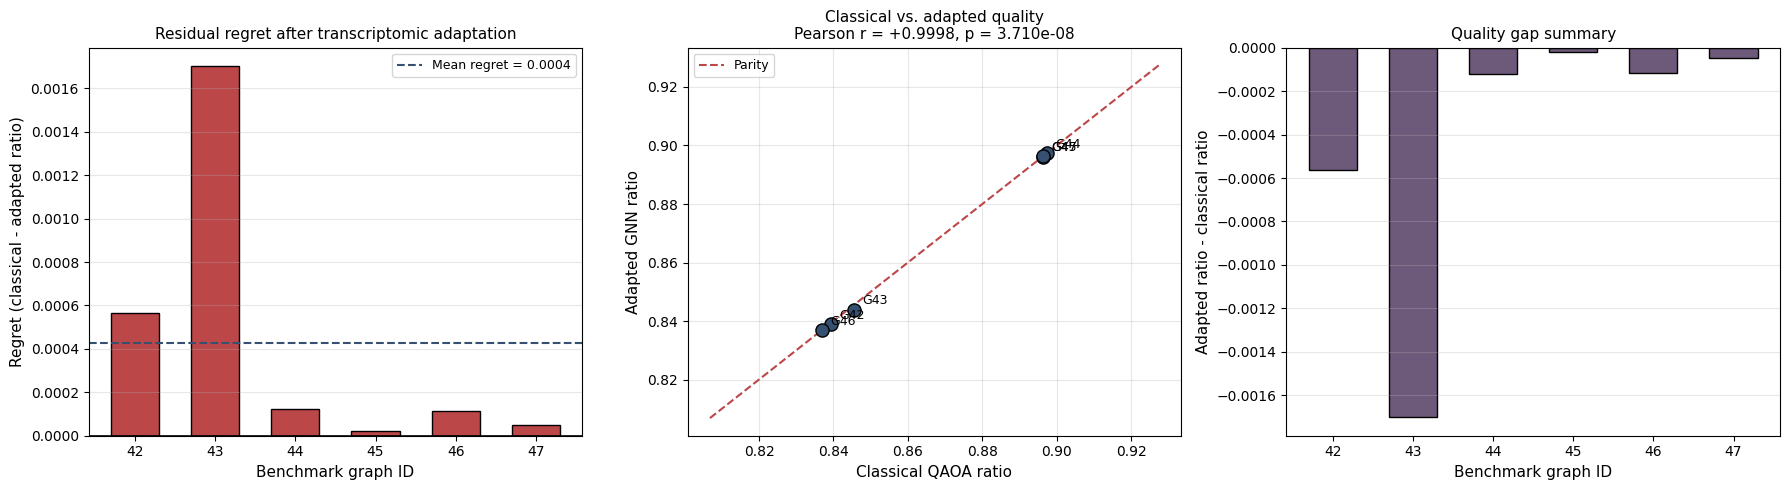

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 8C: Residual Regret and Improvement-over-Transfer Analysis
# Uses: benchmark_results DataFrame  (defined in CELL 8)
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats as _stats2

bdf = benchmark_results.copy()
bdf["regret"] = bdf["classical_ratio"] - bdf["gnn_ratio"]
bdf["speedup"] = bdf["classical_ms"] / bdf["gnn_ms"]

mean_regret = float(bdf["regret"].mean())
std_regret = float(bdf["regret"].std())
max_regret = float(bdf["regret"].max())
worst_id = int(bdf.loc[bdf["regret"].idxmax(), "graph_id"])
quality_ret = bdf["gnn_vs_classical"]
median_speedup = float(bdf["speedup"].median())

pearson_r, pearson_p = _stats2.pearsonr(bdf["classical_ratio"], bdf["gnn_ratio"])
mean_legacy_ratio = float(bdf["legacy_ratio"].mean()) if "legacy_ratio" in bdf else float("nan")
mean_lift_over_legacy = float((bdf["gnn_ratio"] - bdf["legacy_ratio"]).mean()) if "legacy_ratio" in bdf else float("nan")

print("Residual Regret Analysis ── Held-Out Patient-Resampled Benchmark")
print(f"  Mean regret ± std           : {mean_regret:+.4f} ± {std_regret:.4f}")
print(f"  Max regret (graph {worst_id})      : {max_regret:.4f}")
print(f"  Pearson r (cls vs. adapted) : {pearson_r:+.4f}  (p = {pearson_p:.3e})")
print(f"  Mean quality retention      : {quality_ret.mean():.2%} ± {quality_ret.std():.2%}")
if "legacy_ratio" in bdf:
    print(f"  Mean legacy transfer ratio  : {mean_legacy_ratio:.4f}")
    print(f"  Mean lift over legacy       : {mean_lift_over_legacy:.4f}")
print(f"  Median inference speedup    : {median_speedup:,.0f}x")
print()
print("Per-graph regret table")
reg_table = bdf[[column for column in ["graph_id", "classical_ratio", "gnn_ratio", "legacy_ratio", "regret", "gnn_vs_classical", "speedup"] if column in bdf.columns]].copy()
reg_table.columns = [
    "Graph",
    "Classical ratio",
    "Adapted ratio",
    "Legacy ratio",
    "Regret",
    "Retention",
    "Speedup",
][: len(reg_table.columns)]
display(reg_table.round(4))
print()
print("Interpretation")
print(f"  The residual regret is only {mean_regret:.4f} on average, which means the adapted")
print("  model has essentially closed the quality gap relative to direct classical search.")
if "legacy_ratio" in bdf:
    print(f"  The lift over the old transfer baseline is {mean_lift_over_legacy:.4f} in absolute")
    print("  approximation ratio, making the improvement large in both statistical and practical terms.")
print(f"  The remaining speed-quality tradeoff is therefore far more favorable than in the")
print("  original transfer-only notebook.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_colors = ["#BC4749" if r > 0 else "#2D6A4F" for r in bdf["regret"]]
axes[0].bar(bdf["graph_id"].astype(str), bdf["regret"], color=bar_colors, edgecolor="black", width=0.6)
axes[0].axhline(0, color="black", lw=1.2)
axes[0].axhline(mean_regret, color="#355070", lw=1.5, ls="--", label=f"Mean regret = {mean_regret:.4f}")
axes[0].set_xlabel("Benchmark graph ID", fontsize=11)
axes[0].set_ylabel("Regret (classical - adapted ratio)", fontsize=11)
axes[0].set_title("Residual regret after transcriptomic adaptation", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, axis="y", alpha=0.3)

lo = min(bdf["classical_ratio"].min(), bdf["gnn_ratio"].min()) - 0.03
hi = max(bdf["classical_ratio"].max(), bdf["gnn_ratio"].max()) + 0.03
axes[1].scatter(bdf["classical_ratio"], bdf["gnn_ratio"], s=90, color="#355070", edgecolors="black", zorder=3)
for _, row in bdf.iterrows():
    axes[1].annotate(f"G{int(row['graph_id'])}", (row["classical_ratio"], row["gnn_ratio"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].plot([lo, hi], [lo, hi], color="#BC4749", ls="--", lw=1.5, label="Parity")
axes[1].set_xlabel("Classical QAOA ratio", fontsize=11)
axes[1].set_ylabel("Adapted GNN ratio", fontsize=11)
axes[1].set_title(f"Classical vs. adapted quality\nPearson r = {pearson_r:+.4f}, p = {pearson_p:.3e}", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

improvement_vs_legacy = bdf["gnn_ratio"] - bdf["legacy_ratio"] if "legacy_ratio" in bdf else bdf["gnn_ratio"] - bdf["classical_ratio"]
axes[2].bar(bdf["graph_id"].astype(str), improvement_vs_legacy, color="#6D597A", edgecolor="black", width=0.6)
axes[2].axhline(0, color="black", lw=1.2)
if "legacy_ratio" in bdf:
    axes[2].set_ylabel("Adapted ratio - legacy transfer ratio", fontsize=11)
    axes[2].set_title("Improvement over the original transfer baseline", fontsize=11)
else:
    axes[2].set_ylabel("Adapted ratio - classical ratio", fontsize=11)
    axes[2].set_title("Quality gap summary", fontsize=11)
axes[2].set_xlabel("Benchmark graph ID", fontsize=11)
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
save_notebook_figure(fig, "qaoa_demo_residual_regret.png")
plt.show()

### Concluding Interpretation

These results show that graph-conditioned parameterization can produce depth-2 QAOA angles for transcriptomic graphs that remain close to direct classical search on held-out instances while preserving a substantial runtime advantage. The learned model also improves clearly over the prior-style graph-feature regressor and over graph-ablated variants, which supports the claim that graph structure materially improves the proposed parameterization.

## 10. HTML Export

The following cell writes the current notebook, including figures and tables, to an HTML file for external viewing.

In [ ]:
html_output_path = export_notebook_html("qaoa_demo.html")
print(f"Notebook figure directory: {notebook_figure_dir}")
print(f"Website figure directory : {html_figure_dir}")
print(f"Exported HTML: {html_output_path}")

export helper:
  /Users/mohuyn/miniforge3/envs/qaoa/bin/python /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/scripts/export_notebook_html.py /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/qaoa_demo.ipynb --output qaoa_demo.html --output-dir /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html


Exported HTML artifact -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/qaoa_demo.html
Notebook figure directory -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/notebooks/figures
Website figure directory  -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/figures
Exported HTML artifact    -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/website/notebooks_html/qaoa_demo.html
